In [7]:
%load_ext autoreload
%autoreload 2


import numpy as np
import matplotlib
matplotlib.use('Agg')
import warnings
import pandas as pd
from datetime import datetime
from matplotlib import pyplot as plt
import seaborn as sns
from plotnine import *
import statsmodels.formula.api as smf
import statsmodels.api as sm


#Set random seeds
seed = 210226
warnings.filterwarnings('ignore', category=RuntimeWarning)

sns.set_theme(style="white", font_scale=1.2)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
#####-------FILENAMES ETC--------------
dataset_name = "bch" 
raw_file_name = "preprocessed-visits-with-raw-variables"
load_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/BCH-ED/epi-and-prediction/"
save_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/ch265493/BCH-ED/decompensation/"
split_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/BCH-ED/epi-and-prediction/prediction/recent-eval/at-triage/"

raw_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/BCH-ED/raw-data/"


####--------PREPROCESSING VARIABLES------------

#Define identifier columns.
identifier_cols = ["csn", "is_admitted", "mrn", "minutes_since_first_arrival", "raw_arrival_month", "raw_arrival_year"]

#Define excluded columns-- we do not use these as predictors.
excluded_columns = identifier_cols + ["group", "assigned_order"] #These are excluded from both predictions and IPW calculations.
excluded_prefixes = ['current_diagnosis'] #These are excluded from just predictions.

#Identify gendered predictions; we exclude these when matching patients across sex-based groups
gendered_predictors = ['current_diagnosis_menstrual_disorders', 'pre_diagnosis_menstrual_disorders', 'complaint_contains_abdominal_pain',
                       'complaint_contains_gynecologic', 'complaint_contains_male_genital', 'complaint_contains_pregnancy']

#Separate categorical, pre-binarised, and continuous predictors.
categorical_predictors = [
    'race', 'sex', 'ed_arrival_mode', 'language',
                'insurance', 'home_state', 'year_of_arrival', 'season', 'time_of_day', 'triage_acuity']



#Variables which already 'come pre-binarised'.
pre_binarised_predictors = ['is_trans_or_nb', 'is_weekend',
                            'current_diagnosis_epilepsy', 'current_diagnosis_asthma', 'current_diagnosis_congenital_malformations', 
                'current_diagnosis_depression', 'current_diagnosis_pain_conditions', 'current_diagnosis_anxiety',
                  'current_diagnosis_conduct_disorders', 'current_diagnosis_nausea_and_vomiting',
                    'current_diagnosis_any_malignancy', 'current_diagnosis_gastrointestinal', 
                    'current_diagnosis_developmental_delays', 'current_diagnosis_psychotic_disorders', 
                    'current_diagnosis_cardiovascular', 'current_diagnosis_diabetes_mellitus', 'current_diagnosis_eating_disorders', 
                    'current_diagnosis_weight_loss', 'current_diagnosis_anemia', 'current_diagnosis_chromosomal_anomalies', 
                    'current_diagnosis_drug_abuse', 'current_diagnosis_menstrual_disorders', 'current_diagnosis_sleep_disorders', 
                    'current_diagnosis_smoking', 'current_diagnosis_alcohol_abuse', 'current_diagnosis_joint_disorders', 
                      'pre_diagnosis_any_malignancy', 'pre_diagnosis_gastrointestinal', 'pre_diagnosis_nausea_and_vomiting', 
                      'pre_diagnosis_diabetes_mellitus', 'pre_diagnosis_pain_conditions', 'pre_diagnosis_cardiovascular',
                        'pre_diagnosis_developmental_delays', 'pre_diagnosis_epilepsy', 'pre_diagnosis_asthma', 'pre_diagnosis_anemia', 
                        'pre_diagnosis_congenital_malformations', 'pre_diagnosis_conduct_disorders', 'pre_diagnosis_chromosomal_anomalies',
                          'pre_diagnosis_anxiety', 'pre_diagnosis_weight_loss', 'pre_diagnosis_psychotic_disorders', 'pre_diagnosis_drug_abuse',
                            'pre_diagnosis_smoking', 'pre_diagnosis_depression', 'pre_diagnosis_eating_disorders', 'pre_diagnosis_menstrual_disorders', 
                            'pre_diagnosis_sleep_disorders', 'pre_diagnosis_joint_disorders', 'pre_diagnosis_alcohol_abuse', 
                            'complaint_contains_abdominal_pain', 'complaint_contains_assault', 
                            'complaint_contains_allergic_reaction', 'complaint_contains_altered_mental_status',
                              'complaint_contains_asthma_or_wheezing', 'complaint_contains_bites_or_stings', 
                              'complaint_contains_burn', 'complaint_contains_cardiac', 'complaint_contains_chest_pain', 
                              'complaint_contains_chronic_disease', 'complaint_contains_congestion', 'complaint_contains_constipation', 
                              'complaint_contains_cough', 'complaint_contains_croup', 'complaint_contains_crying_or_colic', 'complaint_contains_dental', 
                              'complaint_contains_device_complication', 'complaint_contains_diarrhea', 'complaint_contains_ear_complaint',
                                'complaint_contains_epistaxis', 'complaint_contains_extremity', 'complaint_contains_eye_complaint', 
                                'complaint_contains_syncope', 'complaint_contains_foreign_body', 'complaint_contains_fever', 
                                'complaint_contains_follow_up', 'complaint_contains_general', 'complaint_contains_gi_bleed',
                                  'complaint_contains_gynecologic', 'complaint_contains_head_or_neck', 'complaint_contains_headache', 
                                  'complaint_contains_laceration', 'complaint_contains_lump_or_mass', 'complaint_contains_male_genital', 
                                  'complaint_contains_mvc', 'complaint_contains_neck_pain', 'complaint_contains_neurologic', 
                                  'complaint_contains_poisoning', 'complaint_contains_poor_feeding', 'complaint_contains_pregnancy', 
                                  'complaint_contains_primary_care', 'complaint_contains_psych', 'complaint_contains_rash', 
                                  'complaint_contains_other_respiratory', 'complaint_contains_seizure', 'complaint_contains_sore_throat',
                                    'complaint_contains_trauma', 'complaint_contains_urinary', 'complaint_contains_vomiting',
                    ]


#Continuous predictors.
continuous_predictors = [
    'age_in_days', 'miles_travelled', 'sdi_score',
     'crowdedness',  'raw_weight', 
     'num_previous_admissions', 'num_previous_visits_without_admission',
     'raw_triage_dbp', 'raw_triage_hr', 'raw_triage_pain', 'raw_triage_rr', 'raw_triage_sbp', 'raw_triage_sp_o2',
]



#Map races into groups.
race_dict = {
    'Hispanic': 'H',
    'Hispanic White': 'H',
    'Black': 'NHB',
    'Non-Hispanic Black': 'NHB',
    'Asian' : 'Other',
    'Unknown': 'Other',
    'Other': 'Other',
    'White': 'NHW',
    'Non-Hispanic White' : 'NHW'
}




Build a timeline describing the crowding state of the ED at every arrival.

In [9]:
#Load the visits for these projects.
visits = pd.read_csv(save_filepath + 'intermediate-files/visits.csv', index_col=0)


#Classify visits into urgent and non-urgent. (Assume that everyone with no recorded triage acuity is non-urgent).
visits['urgent'] = ((~visits['triage_acuity'].isna()) & ((visits['triage_acuity'] == 1) | (visits['triage_acuity'] == 2))).astype(int)

#Now all we need is the admission status, urgency status, ED LOS and timeline of arrival.
visit_timeline = visits[['csn', 'urgent', 'is_admitted', 'ed_los', 'minutes_since_first_arrival']].copy().sort_values('minutes_since_first_arrival')

#So we need to keep a running count of how many urgent, non-urgent, admitted and non-admitted patients (that's a 4-way contingency table) there are in the ED at any given time.
visit_timeline['visit_type'] = np.char.add(
    np.char.add(
        np.where(visit_timeline['urgent'] == 1, 'urgent', 'non-urgent'),
        '-'
    ),
    np.where(visit_timeline['is_admitted'] == 1, 'admitted', 'discharged')
)

#Denote timestamps.
visit_timeline = visit_timeline.rename(columns={'minutes_since_first_arrival':'arrival'})
visit_timeline['departure'] = visit_timeline['arrival'] + visit_timeline['ed_los']

#Now get a list of events (arrivals/departures)
events = visit_timeline[['visit_type', 'arrival', 'departure']].melt(
    id_vars=['visit_type'],
    value_vars=['arrival', 'departure'],
    var_name='event',
    value_name='timestamp'
).sort_values('timestamp')


#Now expand the dataframe.
visit_types, event_types, timestamps = events['visit_type'].values, np.where(events['event'].values=='arrival', 1, -1), events['timestamp'].values

#Store crowding information in a dictionary. (This will contain information on repeat timestamps; we can deal with that later)
crowding_history, crowding_current = {}, {}
vtypes = events['visit_type'].unique()
for vtype in vtypes:
    crowding_history[vtype] = np.zeros_like(timestamps) #Number of visits of each type at each [UNIQUE] timestamp- about 10% of timestamps have repeat events
    crowding_current[vtype] = 0 #Instantaneous count of visits in the ED, starting at 0

for index, ts in enumerate(timestamps):
    vtype, etype = visit_types[index], event_types[index]
    for vtype_ in vtypes:
        if vtype == vtype_: #If this is the relevant type:
            new_crowding = crowding_current[vtype_] + etype #Update population.
        else:
            new_crowding = crowding_current[vtype_] #Use last known population.
        
        #Now update the current population.
        crowding_history[vtype_][index] = new_crowding
        crowding_current[vtype_] = new_crowding


#Now make a dataframe out of the crowding history.
crowding_history['timestamp'] = timestamps
crowding_history = pd.DataFrame(crowding_history).reset_index()

#Now just keep the last instance of all unique timestamps (we only need to know how things stood at the end of the minute, once all relevant processes have played out).
indices_to_keep = crowding_history[['timestamp', 'index']].groupby('timestamp').agg('max').reset_index()
crowding_history = crowding_history.merge(indices_to_keep[['index']], on='index', how='inner').reset_index(drop=True).drop(columns=['index'])

#Save this.
crowding_history.to_csv(save_filepath+'crowding-history.csv')

#Attach this back to visit timeline.
visit_timeline = visit_timeline.merge(crowding_history, left_on='arrival', right_on='timestamp', how='inner').drop(columns=['timestamp', 'departure'])
visit_timeline.to_csv(save_filepath+'visit-timeline.csv')


/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_89669/4290237612.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.


Now see if we can fit a distribution to these 'times-to-arrival'. (If not, the crowding history will nonetheless be helpful for predicting individual level ED-LOS with RNNs, for which we'd need admission status and visit diagnoses).

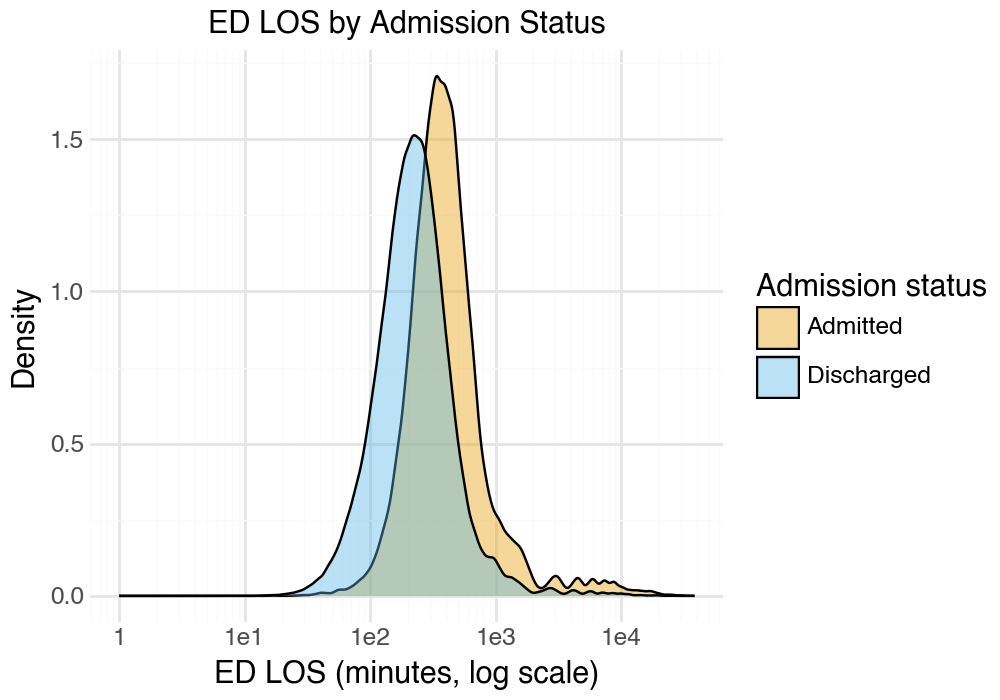

In [10]:
#Load this.
%matplotlib inline
import pandas as pd
from plotnine import (
    ggplot, aes, geom_density, scale_x_log10, scale_fill_manual,
    labs, theme, theme_minimal, element_text
)

visit_timeline = pd.read_csv(save_filepath+'visit-timeline.csv', index_col=0)

#-----COLORBLIND-SAFE PALETTE (Okabe-Ito)-----
#Chosen for maximum distinguishability under the common forms of colour vision deficiency
#(deuteranopia/protanopia/tritanopia), rather than relying on plotnine's default hues, which
#are not colorblind-safe.
OKABE_ITO = [
    '#E69F00',  # orange
    '#56B4E9',  # sky blue
    '#009E73',  # bluish green
    '#D55E00',  # vermillion
    '#0072B2',  # blue
    '#CC79A7',  # reddish purple
    '#F0E442',  # yellow
    '#000000',  # black
]

#-----HUMAN-READABLE LABELS-----
#Mapping raw coded values (0/1, or raw hyphenated visit_type strings) to display-only labels.
#Only ever applied to a COPY of the data for plotting -- the raw columns (used elsewhere, e.g.
#the crowding-effects simulation, which matches on the exact lowercase-hyphenated visit_type
#strings) are left untouched.
ADMISSION_LABELS = {1: 'Admitted', 0: 'Discharged'}
URGENCY_LABELS = {1: 'Urgent', 0: 'Non-urgent'}
VISIT_TYPE_LABELS = {
    'non-urgent-discharged': 'Non-urgent, discharged',
    'non-urgent-admitted': 'Non-urgent, admitted',
    'urgent-discharged': 'Urgent, discharged',
    'urgent-admitted': 'Urgent, admitted',
}

plot_df = visit_timeline.copy()
plot_df['admission_status'] = plot_df['is_admitted'].map(ADMISSION_LABELS)
plot_df['urgency_status'] = plot_df['urgent'].map(URGENCY_LABELS)
plot_df['visit_type_label'] = plot_df['visit_type'].map(VISIT_TYPE_LABELS)
#Guard against any value not covered above (e.g. a new/typo'd category) showing up as a silent
#NaN in the plot -- fall back to the raw value rather than dropping the row.
plot_df['visit_type_label'] = plot_df['visit_type_label'].fillna(plot_df['visit_type'])

def los_density_plot(df, fill_col, title, legend_title=''):
    categories = sorted(df[fill_col].dropna().unique().tolist())
    if len(categories) > len(OKABE_ITO):
        raise ValueError(
            f"{len(categories)} categories in '{fill_col}' but only {len(OKABE_ITO)} "
            f"colorblind-safe colours defined -- add more to OKABE_ITO or group categories."
        )
    palette = dict(zip(categories, OKABE_ITO))

    return (
        ggplot(df, aes(x='ed_los', fill=fill_col))
        + geom_density(alpha=0.4)
        + scale_x_log10()
        + scale_fill_manual(values=palette)
        + labs(title=title, x='ED LOS (minutes, log scale)', y='Density', fill=legend_title)
        + theme_minimal()
        + theme(figure_size=(5, 3.5), plot_title=element_text(size=11))
    )
#Plot by admission status.
los_density_plot(plot_df, 'admission_status', 'ED LOS by Admission Status', legend_title='Admission status')


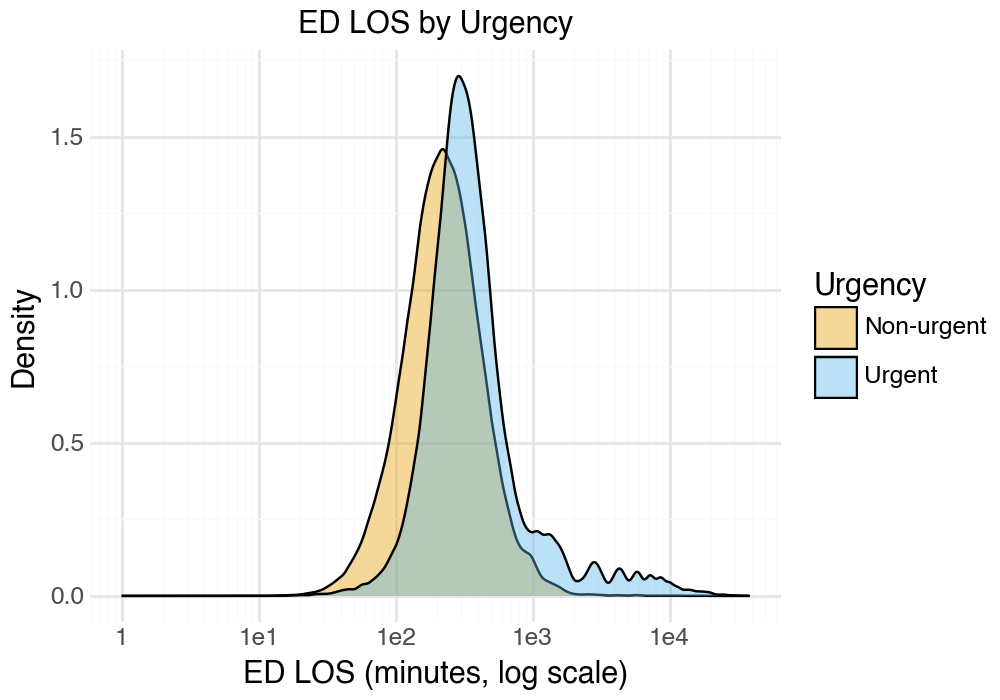

In [11]:

#Plot by urgency.
los_density_plot(plot_df, 'urgency_status', 'ED LOS by Urgency', legend_title='Urgency')


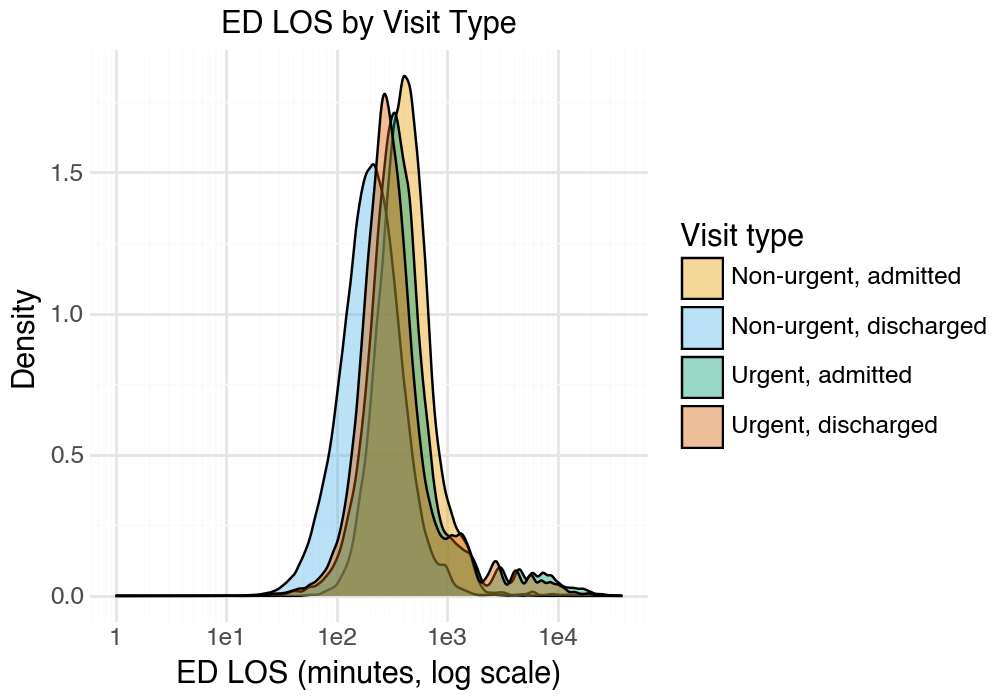

In [12]:

#Plot by visit type.
los_density_plot(plot_df, 'visit_type_label', 'ED LOS by Visit Type', legend_title='Visit type')


/opt/anaconda3/lib/python3.12/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


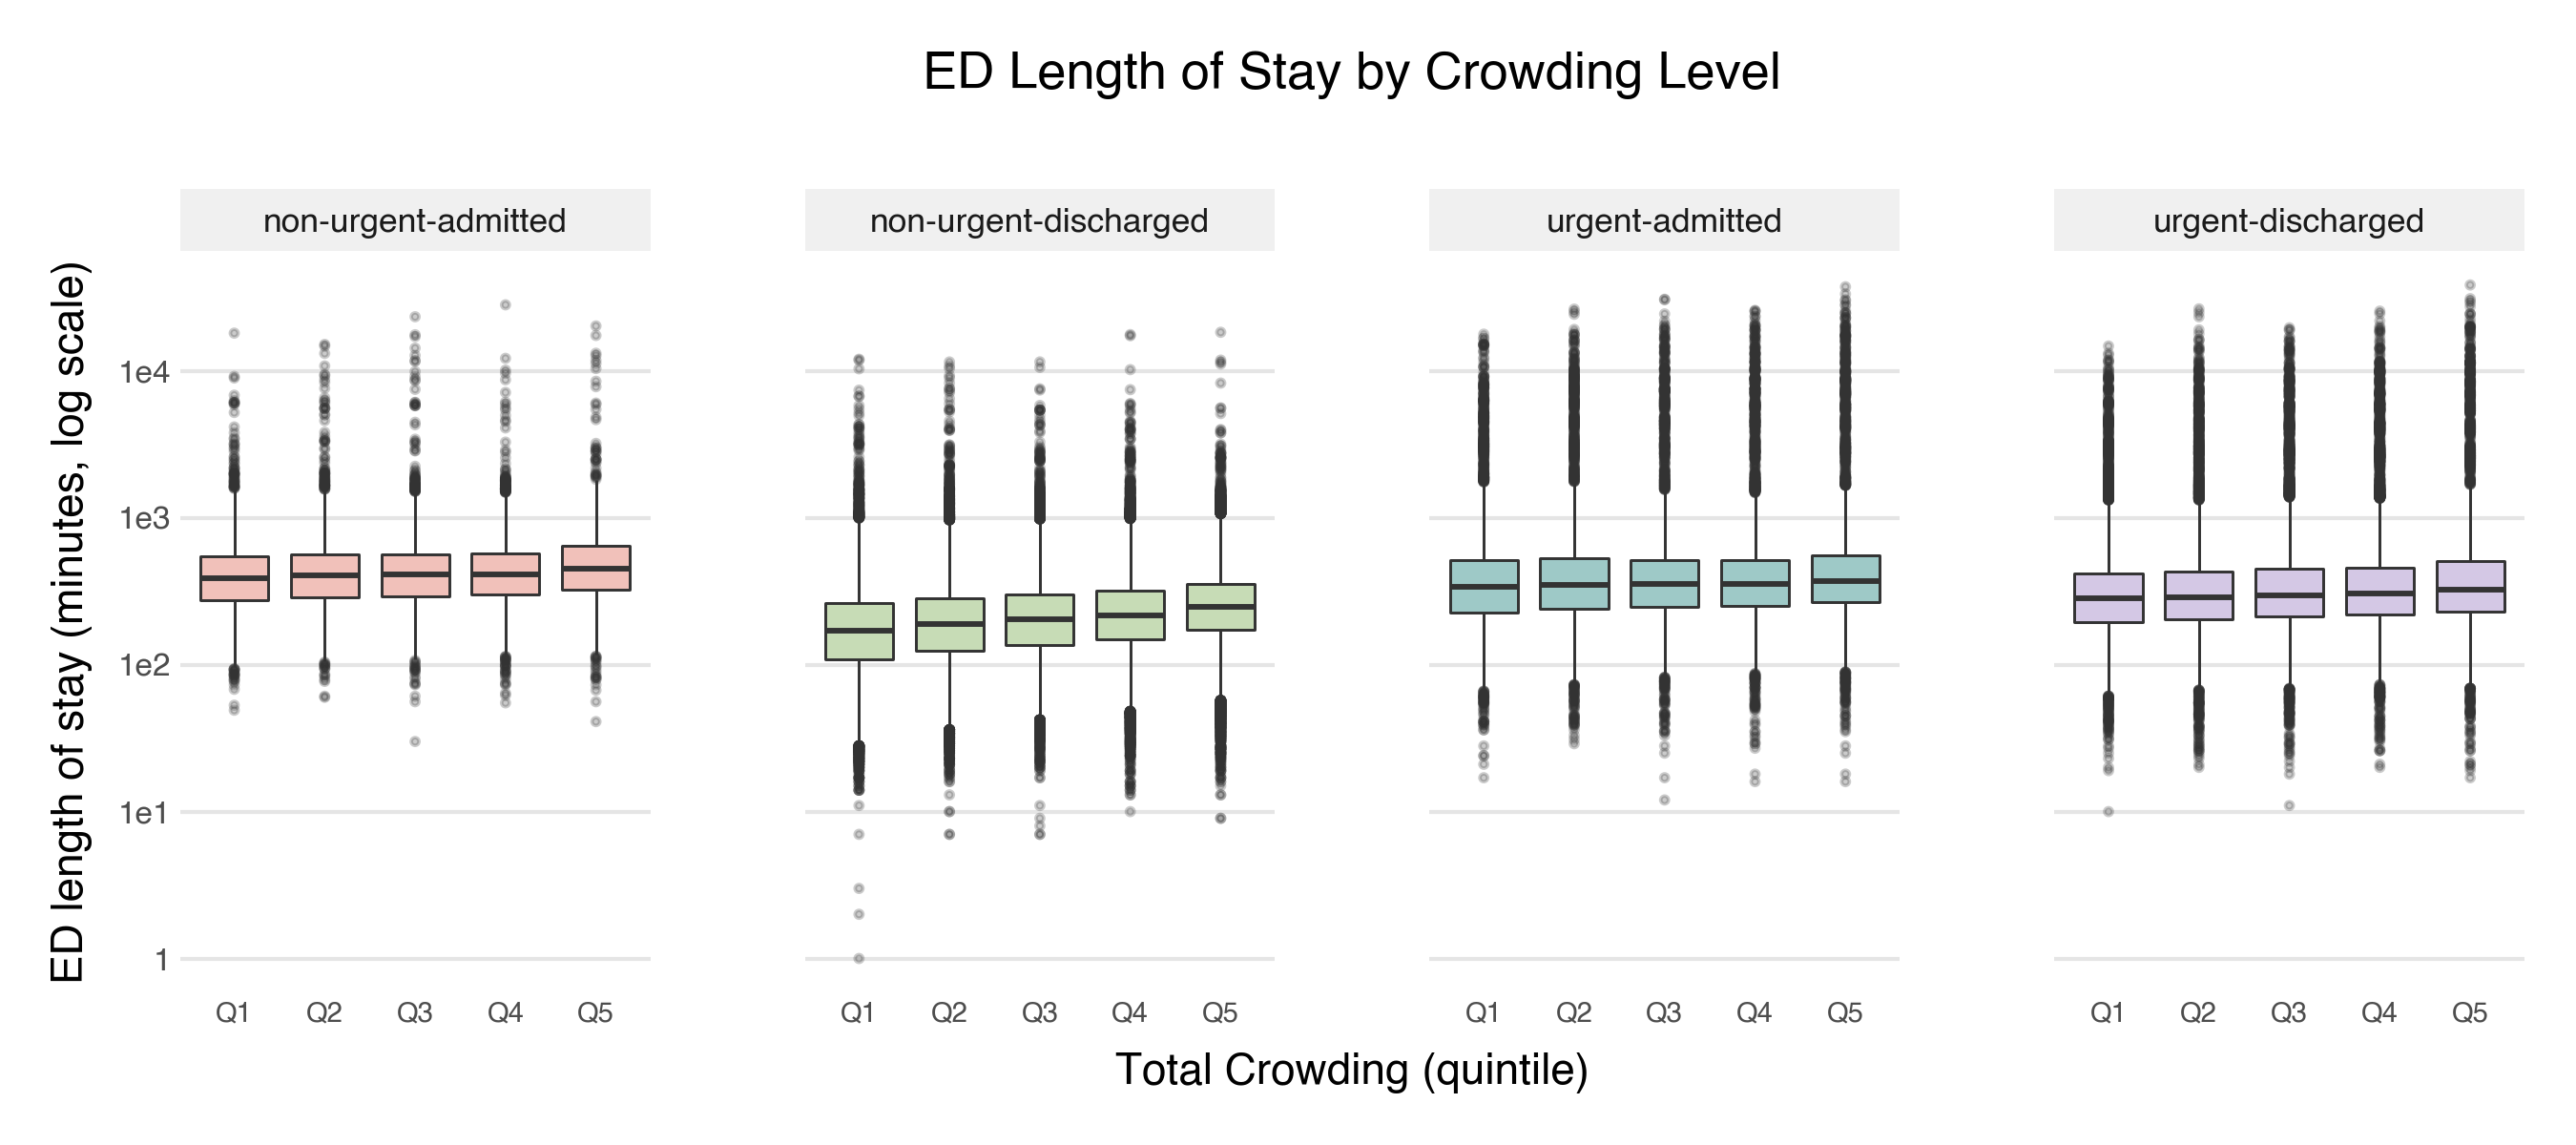

/opt/anaconda3/lib/python3.12/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


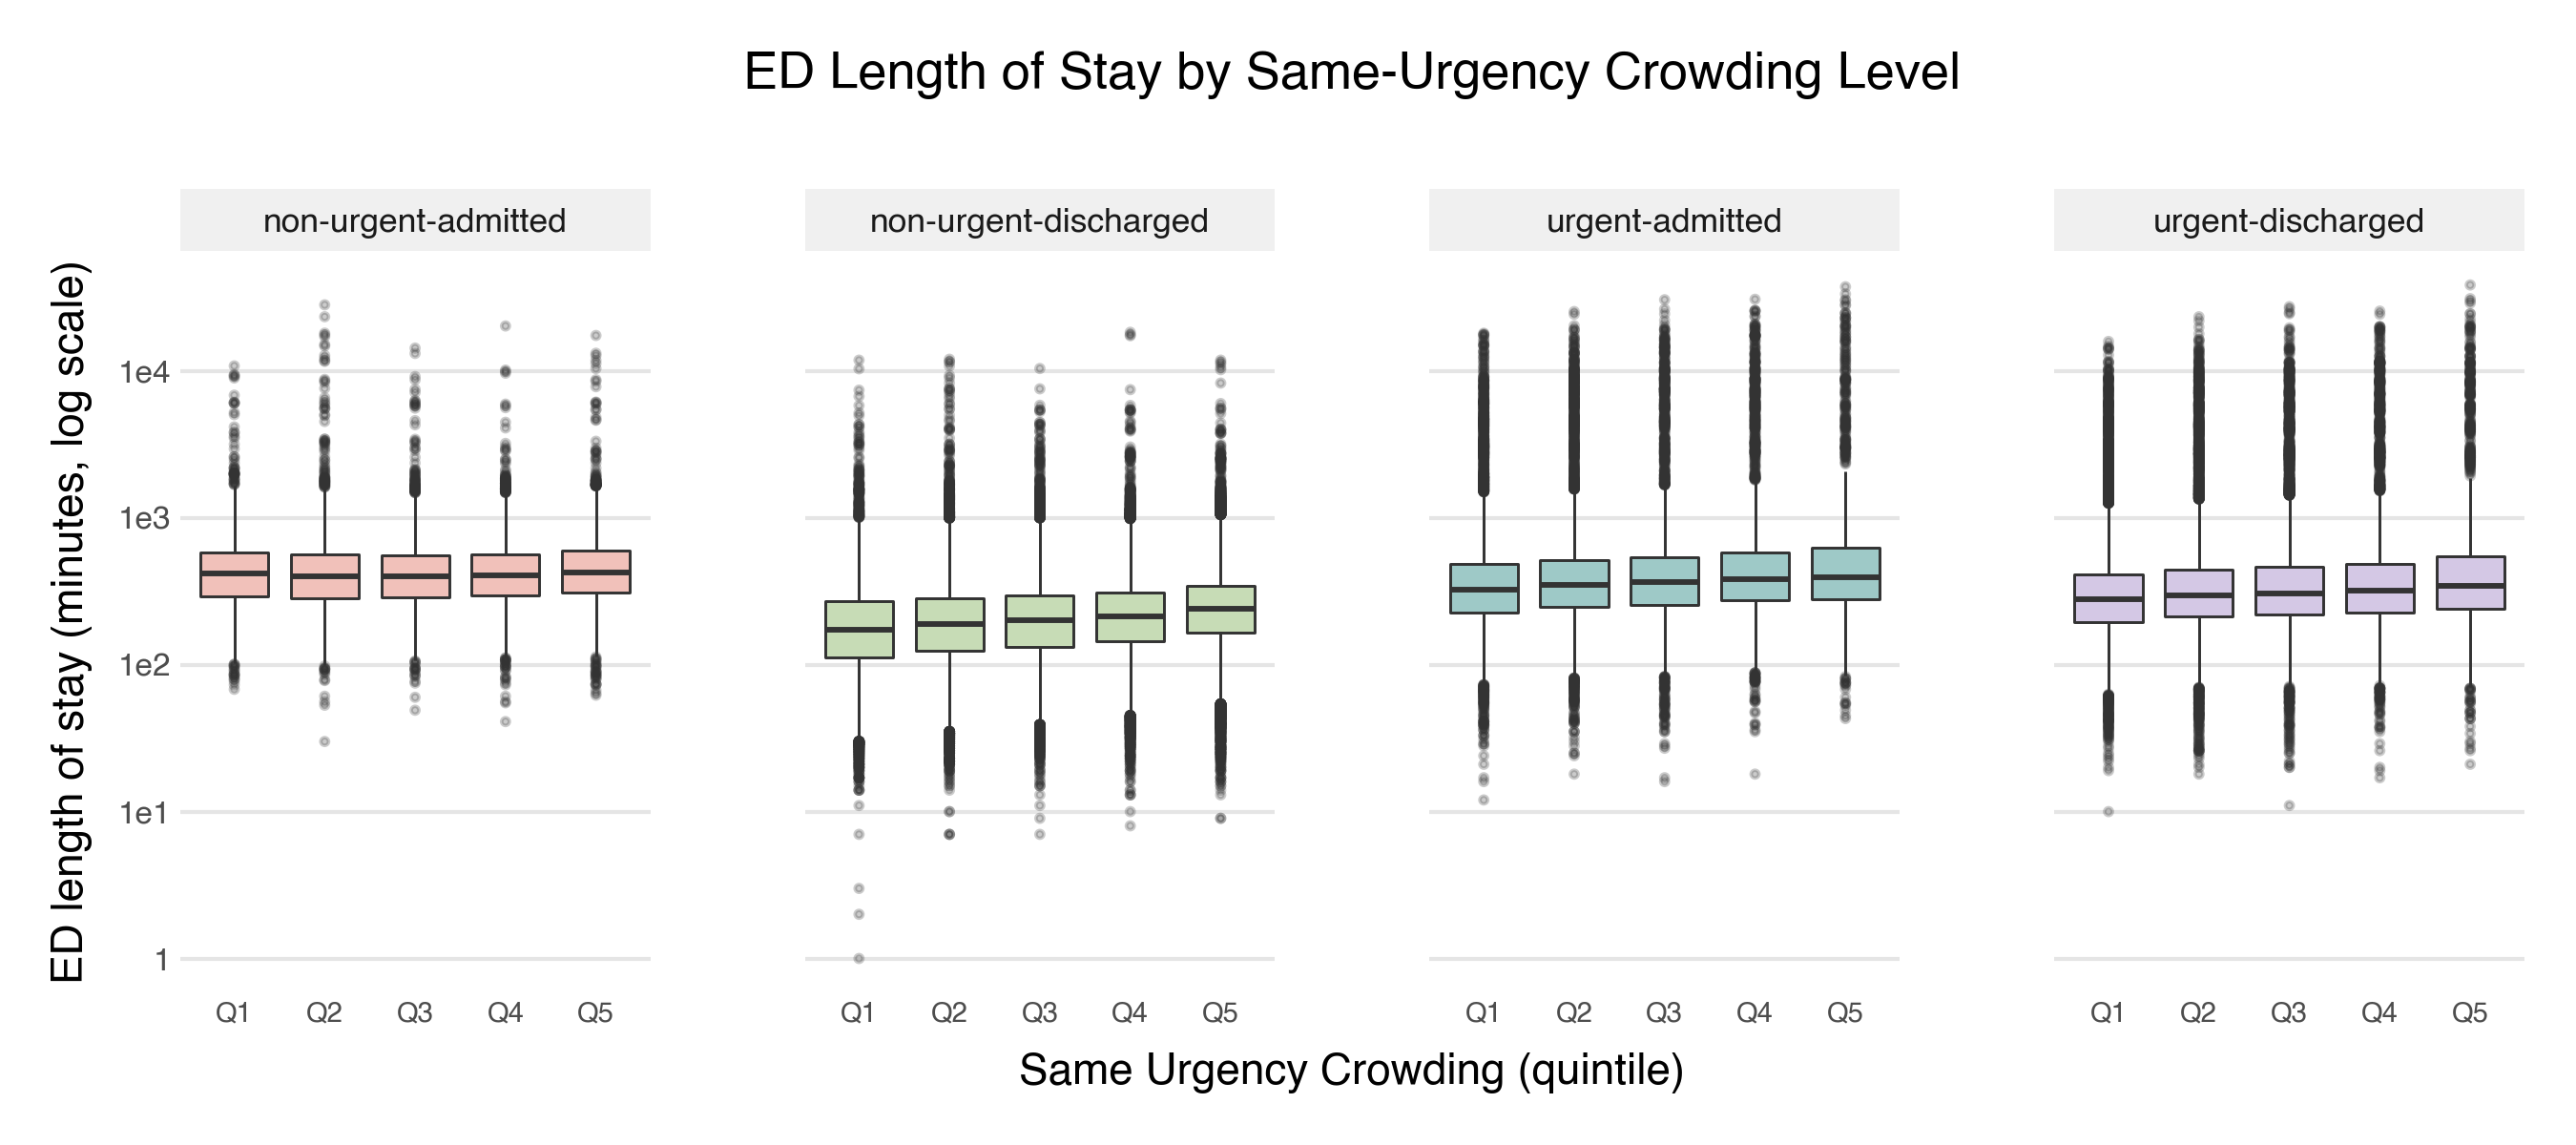

/opt/anaconda3/lib/python3.12/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


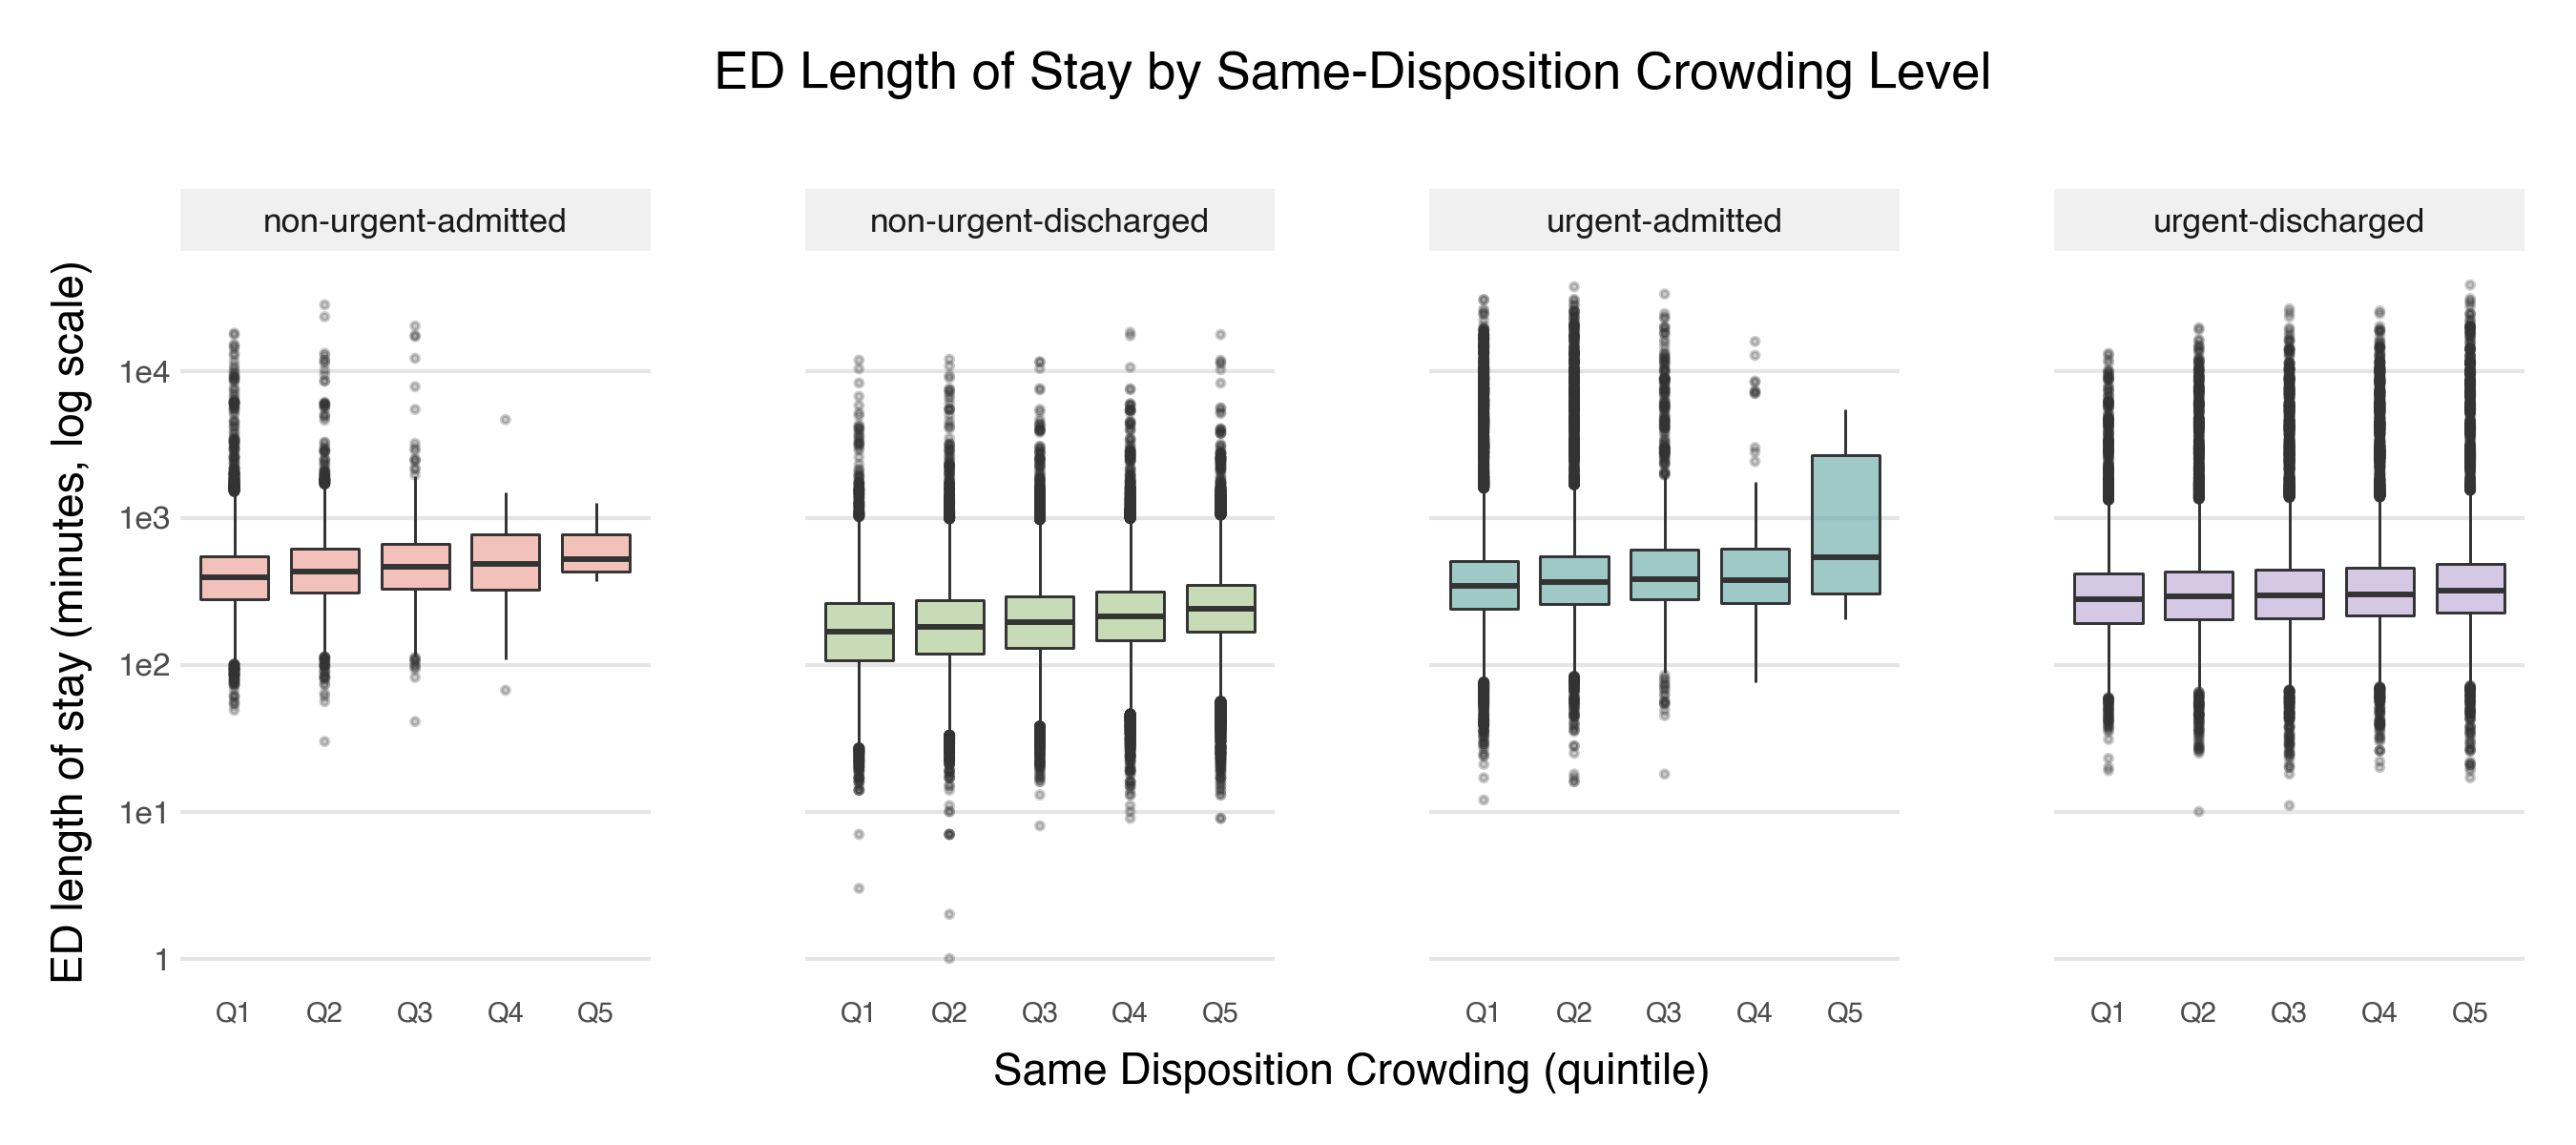

/opt/anaconda3/lib/python3.12/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


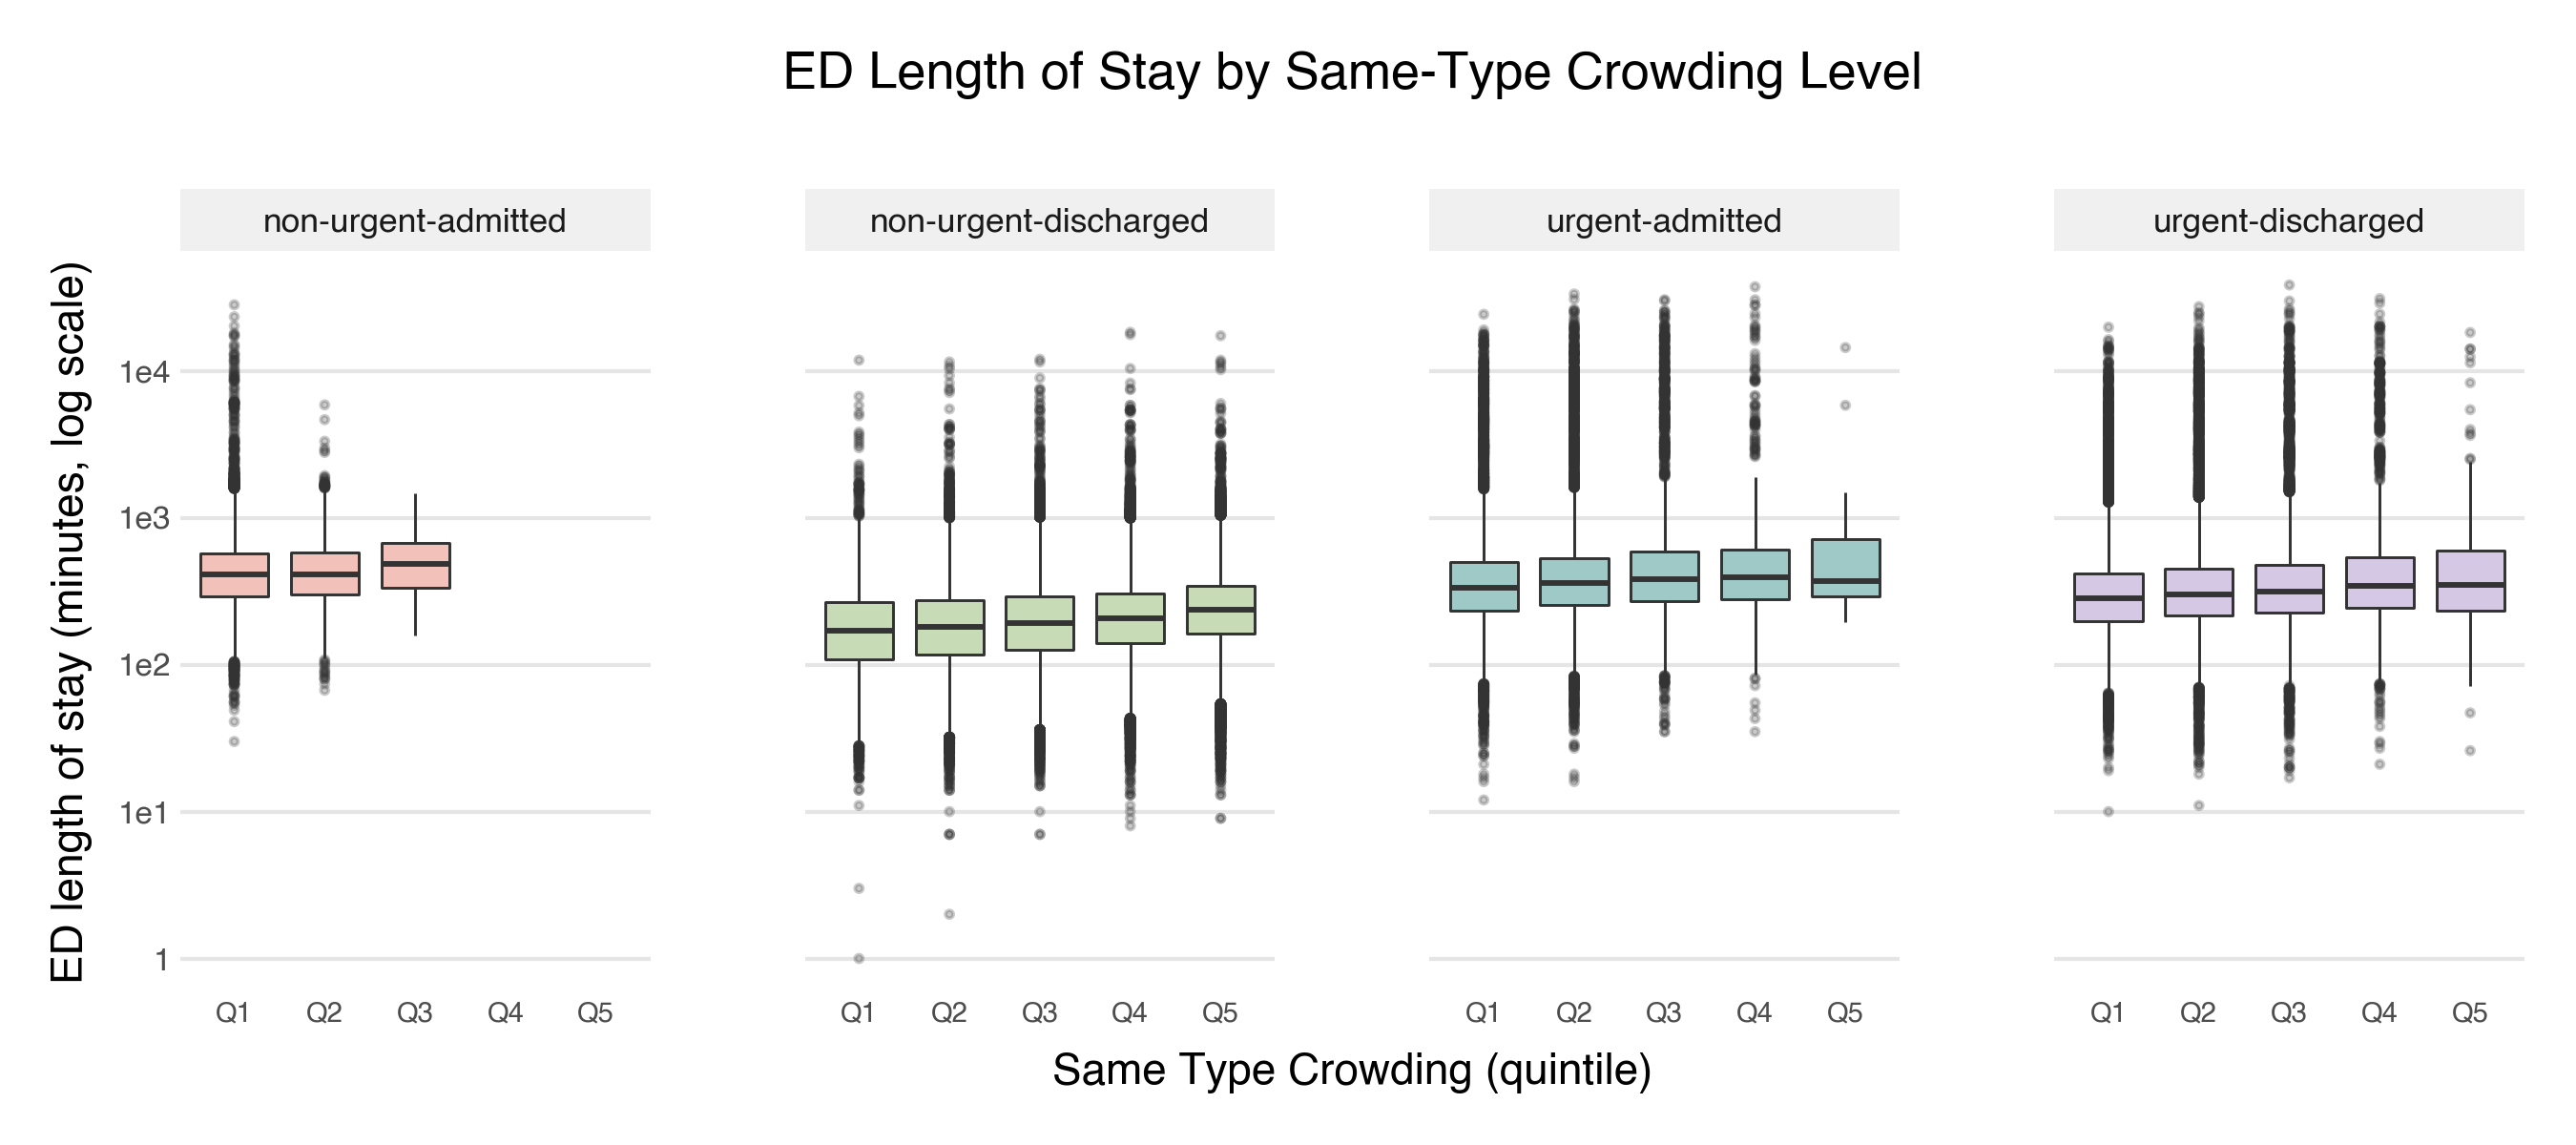

In [13]:
%matplotlib inline

import pandas as pd
import numpy as np
from plotnine import *

# Load data
visit_timeline = pd.read_csv(save_filepath + 'visit-timeline.csv', index_col=0)
visit_timeline['log_ed_los'] = np.log(visit_timeline['ed_los'])
visit_timeline['total-crowding'] = (
    visit_timeline['non-urgent-admitted'] + visit_timeline['urgent-admitted']
    + visit_timeline['urgent-discharged'] + visit_timeline['non-urgent-discharged']
)

#Collate crowding types.
visit_timeline['urgent-crowding'] = visit_timeline['urgent-discharged'] + visit_timeline['urgent-admitted']
visit_timeline['non-urgent-crowding'] = visit_timeline['non-urgent-admitted'] + visit_timeline['non-urgent-discharged']
visit_timeline['admit-crowding'] = visit_timeline['urgent-discharged'] + visit_timeline['non-urgent-admitted']
visit_timeline['discharge-crowding'] = visit_timeline['non-urgent-discharged'] + visit_timeline['urgent-discharged']
visit_timeline['same-urgency-crowding'] = np.where(visit_timeline['visit_type'].isin(['urgent-admitted', 'urgent-discharged']), visit_timeline['urgent-crowding'], visit_timeline['non-urgent-crowding'])
visit_timeline['same-disposition-crowding'] = np.where(visit_timeline['visit_type'].isin(['urgent-admitted', 'non-urgent-admitted']), visit_timeline['admit-crowding'], visit_timeline['discharge-crowding'])


#Get crowding of the same type.
crowding_cols = ['non-urgent-admitted', 'non-urgent-discharged', 'urgent-admitted', 'urgent-discharged']
conditions = [visit_timeline['visit_type'] == c for c in crowding_cols]
choices = [visit_timeline[c] for c in crowding_cols]
visit_timeline['same-type-crowding'] = np.select(conditions, choices)

#Save these.
visit_timeline.to_csv(save_filepath + 'intermediate-files/visit-timeline-with-summed-crowding.csv')


#Load back data.
visit_timeline = pd.read_csv(save_filepath + 'intermediate-files/visit-timeline-with-summed-crowding.csv', index_col=0)

# Nicer palette (soft but distinct)
crowding_colors = {
    'non-urgent-admitted': '#E8998D',
    'non-urgent-discharged': '#A3C586',
    'urgent-admitted': '#5DA5A3',
    'urgent-discharged': '#B8A4D4',
}
def crowding_plot(df, crowding_type, title, bins=5):
    df_binned = df.copy()
    df_binned['crowding_binned'] = pd.qcut(
        df[crowding_type], q=bins,
        labels=[f'Q{i+1}' for i in range(bins)]
    )

    return (
        ggplot(df_binned, aes(x='crowding_binned', y='ed_los', fill='visit_type'))
        + geom_boxplot(alpha=0.6, outlier_size=0.6, outlier_alpha=0.25, size=0.4)
        + scale_y_log10()
        + scale_fill_manual(values=crowding_colors)
        + facet_grid('~ visit_type')
        + labs(
            title=title,
            y='ED length of stay (minutes, log scale)',
            x=f'{crowding_type.replace("-", " ").title()} (quintile)',
            fill=''
        )
        + theme_minimal(base_size=11)
        + theme(
            figure_size=(9, 4),          # was 10x4.5 — too wide relative to content
            dpi=150,
            plot_title=element_text(size=13, weight='bold', margin={'b': 10}),
            strip_text=element_text(size=8.5, weight='bold'),
            strip_background=element_rect(fill='#F0F0F0', color='none'),
            axis_text_x=element_text(size=7, rotation=0),  # Q1-Q5 short enough to stay horizontal
            axis_text_y=element_text(size=8),
            panel_spacing=0.06,           
            panel_grid_minor=element_blank(),
            panel_grid_major_x=element_blank(),
            legend_position='none',
            plot_margin=0.02,
            subplots_adjust={'right': 0.98},  # stop the last strip label clipping
        )
    )

#Illustrate responsiveness to overall crowding.
p = crowding_plot(visit_timeline, 'total-crowding', 'ED Length of Stay by Crowding Level')
p.show()

#Illustrate responsiveness to same-urgency crowding.
p = crowding_plot(visit_timeline, 'same-urgency-crowding', 'ED Length of Stay by Same-Urgency Crowding Level')
p.show()

#Illustrate responsiveness to same-urgency crowding.
p = crowding_plot(visit_timeline, 'same-disposition-crowding', 'ED Length of Stay by Same-Disposition Crowding Level')
p.show()

#Illustrate responsiveness to same-type crowding.
p = crowding_plot(visit_timeline, 'same-type-crowding', 'ED Length of Stay by Same-Type Crowding Level')
p.show()

In [14]:
# --------------------------------------------------------------------------
# Age banding for age-specific vital-sign normalization.
#
# Pediatric vitals (HR, RR, BP, etc.) have very different normal ranges by
# age - a heart rate that's normal for a 2-month-old is a tachycardia for a
# 10-year-old. Z-scoring across the whole population would wash that out, so
# age-dependent columns get their mean/std/median computed WITHIN each band
# instead of globally. Bin edges are in days for exact, unambiguous cutoffs.
# --------------------------------------------------------------------------
DAYS_PER_MONTH = 30.4375   # 365.25 / 12, for unambiguous month cutoffs
DAYS_PER_YEAR = 365.25

AGE_BIN_EDGES_DAYS = [
    0,
    3 * DAYS_PER_MONTH,
    6 * DAYS_PER_MONTH,
    12 * DAYS_PER_MONTH,
    18 * DAYS_PER_MONTH,
    36 * DAYS_PER_MONTH,
    5 * DAYS_PER_YEAR,
    10 * DAYS_PER_YEAR,
    15 * DAYS_PER_YEAR,
    np.inf,
]
AGE_BIN_LABELS = [
    "0-3mo", "3-6mo", "6-12mo", "12-18mo", "18-36mo",
    "3-5y", "5-10y", "10-15y", "15+",
]
UNKNOWN_AGE_GROUP = "unknown"  # fallback bucket for missing/out-of-range ages


def assign_age_group(df: pd.DataFrame, age_col: str, age_group_col: str = "age_group") -> pd.DataFrame:
    """
    Adds an age_group categorical column from a numeric age_in_days column.
    Bins are left-inclusive/right-exclusive (e.g. "0-3mo" = [0, 3mo)).
    Missing or negative/invalid ages fall back to a shared "unknown" bucket
    rather than becoming NaN, so every row still has a usable group.
    """
    df = df.copy()
    age_days = df[age_col]
    group = pd.cut(age_days, bins=AGE_BIN_EDGES_DAYS, labels=AGE_BIN_LABELS,
                    right=False, include_lowest=True)
    df[age_group_col] = group.astype(object)
    df[age_group_col] = df[age_group_col].where(age_days.notna() & (age_days >= 0), UNKNOWN_AGE_GROUP)
    df[age_group_col] = df[age_group_col].fillna(UNKNOWN_AGE_GROUP)
    return df



In [15]:
#Fit a log-normal model to each visit type.

#Load data and attach seasonality.
visit_timeline = pd.read_csv(save_filepath + 'intermediate-files/visit-timeline-with-summed-crowding.csv', index_col=0)
visits = pd.read_csv(save_filepath + 'intermediate-files/visits.csv', index_col=0)
visits = assign_age_group(visits, age_col='age_in_days') #Assign age group.


#Extract complaints.
complaints = ['complaint_contains_asthma_or_wheezing', 'complaint_contains_bites_or_stings', 
                              'complaint_contains_burn', 'complaint_contains_cardiac', 'complaint_contains_chest_pain', 
                              'complaint_contains_chronic_disease', 'complaint_contains_congestion', 'complaint_contains_constipation', 
                              'complaint_contains_cough', 'complaint_contains_croup', 'complaint_contains_crying_or_colic', 'complaint_contains_dental', 
                              'complaint_contains_device_complication', 'complaint_contains_diarrhea', 'complaint_contains_ear_complaint',
                                'complaint_contains_epistaxis', 'complaint_contains_extremity', 'complaint_contains_eye_complaint', 
                                'complaint_contains_syncope', 'complaint_contains_foreign_body', 'complaint_contains_fever', 
                                'complaint_contains_follow_up', 'complaint_contains_general', 'complaint_contains_gi_bleed',
                                  'complaint_contains_gynecologic', 'complaint_contains_head_or_neck', 'complaint_contains_headache', 
                                  'complaint_contains_laceration', 'complaint_contains_lump_or_mass', 'complaint_contains_male_genital', 
                                  'complaint_contains_mvc', 'complaint_contains_neck_pain', 'complaint_contains_neurologic', 
                                  'complaint_contains_poisoning', 'complaint_contains_poor_feeding', 'complaint_contains_pregnancy', 
                                  'complaint_contains_primary_care', 'complaint_contains_psych', 'complaint_contains_rash', 
                                  'complaint_contains_other_respiratory', 'complaint_contains_seizure', 'complaint_contains_sore_throat',
                                    'complaint_contains_trauma', 'complaint_contains_urinary', 'complaint_contains_vomiting']

preconditions = ['pre_diagnosis_any_malignancy', 'pre_diagnosis_gastrointestinal', 'pre_diagnosis_nausea_and_vomiting', 
                      'pre_diagnosis_diabetes_mellitus', 'pre_diagnosis_pain_conditions', 'pre_diagnosis_cardiovascular',
                        'pre_diagnosis_developmental_delays', 'pre_diagnosis_epilepsy', 'pre_diagnosis_asthma', 'pre_diagnosis_anemia', 
                        'pre_diagnosis_congenital_malformations', 'pre_diagnosis_conduct_disorders', 'pre_diagnosis_chromosomal_anomalies',
                          'pre_diagnosis_anxiety', 'pre_diagnosis_weight_loss', 'pre_diagnosis_psychotic_disorders', 'pre_diagnosis_drug_abuse',
                            'pre_diagnosis_smoking', 'pre_diagnosis_depression', 'pre_diagnosis_eating_disorders', 'pre_diagnosis_menstrual_disorders', 
                            'pre_diagnosis_sleep_disorders', 'pre_diagnosis_joint_disorders', 'pre_diagnosis_alcohol_abuse']

visit_timeline = visit_timeline.merge(visits[['csn', 'is_weekend', 'season', 'year_of_arrival', 'time_of_day',
                                              'age_group', 'insurance', 'ed_arrival_mode', 'language', 'race', 'sex',
                                              'physician_or_hospital_referral', 'miles_travelled', 'num_previous_admissions', 'num_previous_visits_without_admission'] +
                                              complaints + preconditions], on="csn", how='inner')

#We are interested in the effects of crowding on each model. Fit a model and control for chief complaint, miles travelled, age_
formula = "log_ed_los ~ is_weekend + C(season) + C(time_of_day) + C(year_of_arrival) " \
"+ C(ed_arrival_mode) + C(insurance) + C(language) + C(race) + C(sex) + C(age_group) + " \
"physician_or_hospital_referral + miles_travelled + num_previous_admissions + num_previous_visits_without_admission + " \
+ " + ".join(complaints) + " + " + " + ".join(preconditions) + " + C(visit_type)  + C(visit_type):(Q('non-urgent-discharged') + Q('urgent-admitted') + Q('urgent-discharged') + Q('non-urgent-admitted'))"

#Fit a single model in which everything interacts with visit-type.
model = smf.ols(formula, data=visit_timeline).fit()

ci = model.conf_int(alpha=0.05)
ci.columns = ['ci_lower', 'ci_upper']

summary_df = pd.DataFrame({
    'param': model.params.index,
    'exp(coef)': np.exp(model.params.values),
    'std_err': model.bse.values,
    'p_value': model.pvalues.values,
    'exp(ci_lower)': np.exp(ci['ci_lower'].values),
    'exp(ci_upper)': np.exp(ci['ci_upper'].values),
})

summary_df.to_csv(save_filepath + '/outputs/visit-type-crowding-lognormal-coeffs.csv')
summary_df

model.save("ed-los-model.pkl")


/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_89669/2922091635.py:5: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.


In [16]:
import pandas as pd
import re
from itertools import combinations

def pairwise_visit_type_effects(model, visit_type_param_map, alpha=0.05, ref_state='C(visit_type)[T.non-urgent-admitted]'):
    """
    model: fitted statsmodels OLS result (log-scale outcome)
    visit_type_param_map: dict mapping display name -> patsy param name,
        e.g. {'Non-Urgent, Discharged': "C(visit_type)[T.non-urgent-discharged]", ...}
        Include the reference category with param name None.
    """
    from scipy.stats import norm
    z = norm.ppf(1 - alpha / 2)

    cov = model.cov_params()
    params = model.params

    states = list(visit_type_param_map.keys())
    records = []

    for state_from, state_to in combinations(states, 2):
        p_from = visit_type_param_map[state_from]
        p_to = visit_type_param_map[state_to]

        # coefficient relative to reference (0 if this IS the reference)
        beta_from = params[p_from] if p_from != ref_state else 0.0
        beta_to = params[p_to] if p_to != ref_state else 0.0

        # variance/covariance lookups, treating reference as fixed (variance 0, cov 0)
        var_from = cov.loc[p_from, p_from] if p_from != ref_state else 0.0
        var_to = cov.loc[p_to, p_to] if p_to != ref_state else 0.0
        cov_ft = cov.loc[p_from, p_to] if (p_from != ref_state and p_to != ref_state) else 0.0

        # switching FROM state_from TO state_to
        diff = beta_to - beta_from
        var_diff = var_to + var_from - 2 * cov_ft
        se_diff = np.sqrt(var_diff)

        pct_change = (np.exp(diff) - 1) 
        pct_lc = (np.exp(diff - z * se_diff) - 1) 
        pct_uc = (np.exp(diff + z * se_diff) - 1) 

        records.append({
            'from': state_from, 'to': state_to,
            'ED LOS Change [Est.]': pct_change,
            'ED LOS Change [LC]': pct_lc, 'ED LOS Change [UC]': pct_uc,
            'log_est':diff,
            'se':se_diff
        })
        # and the reverse direction (switching the other way)
        records.append({
            'from': state_to, 'to': state_from,
            'ED LOS Change [Est.]': -pct_change if False else (np.exp(-diff) - 1),
            'ED LOS Change [LC]': (np.exp(-diff - z * se_diff) - 1),
            'ED LOS Change [UC]': (np.exp(-diff + z * se_diff) - 1),
            'log_est':-diff,
            'se':se_diff,
        })

    return pd.DataFrame(records)

def parse_interaction_params(param_names):
    """
    Parse patsy interaction term names of the form:
    "C(visit_type)[level]:Q('crowding_type')"
    into a dataframe with separate visit_type and crowding_type columns.
    """
    pattern = re.compile(r"C\(visit_type\)\[([^\]]+)\]:Q\('([^']+)'\)")

    records = []
    for name in param_names:
        match = pattern.match(name)
        if match:
            visit_type, crowding_type = match.groups()
            records.append({
                'param': name,
                'visit_type': visit_type,
                'crowding_type': crowding_type
            })
        else:
            records.append({
                'param': name,
                'visit_type': None,
                'crowding_type': None
            })

    return pd.DataFrame(records)


#Format
def format_ci(row, mode='1sf'):
    est = row['ED LOS Change [Est.]'] * 100
    lc = row['ED LOS Change [LC]'] * 100
    uc = row['ED LOS Change [UC]'] * 100
    if mode=='1sf':
        return f"{est:.1f} ({lc:.1f}\u2013{uc:.1f})"
    else:
        return f"{est:.2f} ({lc:.2f}\u2013{uc:.2f})"

###-----LOAD COEFFICIENTS--------------------

#Load coefficients.
summary_df = pd.read_csv(save_filepath + '/outputs/visit-type-crowding-lognormal-coeffs.csv', index_col=0)

#Isolate coefficients of interest.
params_of_interest = summary_df[summary_df['param'].str.contains('urgent') | summary_df['param'].str.contains('admitted') | summary_df['param'].str.contains('discharged')].copy().reset_index(drop=True)

params_of_interest['ED LOS Change [Est.]'] = params_of_interest['exp(coef)']-1
params_of_interest['ED LOS Change [LC]'] = params_of_interest['exp(ci_lower)']-1
params_of_interest['ED LOS Change [UC]'] = params_of_interest['exp(ci_upper)']-1

#Extract names.
visit_type_names = {'C(visit_type)[T.non-urgent-discharged]': 'Non-Urgent, Discharged',
                    'C(visit_type)[T.urgent-admitted]':'Urgent, Admitted',
                    'C(visit_type)[T.urgent-discharged]': 'Urgent, Discharged',
                    'C(visit_type)[T.non-urgent-admitted]': 'Non-Urgent, Admitted'}

name_dict = {'non-urgent-discharged': 'Non-Urgent, Discharged',
                    'urgent-admitted':'Urgent, Admitted',
                    'urgent-discharged': 'Urgent, Discharged',
                    'non-urgent-admitted': 'Non-Urgent, Admitted'}



#Extract tables and relatable 
visit_type_effects = params_of_interest[~params_of_interest['param'].str.contains('Q')].copy().reset_index(drop=True)
visit_type_effects['Urgency-Disposition'] = visit_type_effects['param'].map(visit_type_names)

#Get estimates of the effects of switching from one state to another.
switching_effects = pairwise_visit_type_effects(model, visit_type_param_map={value: key for key, value in visit_type_names.items()})
switching_effects['ED LOS Change (%) [95% CI]'] = switching_effects.apply(format_ci, axis=1)

#Get estimates of the effect of 1 extra patients on crowding.
crowding_effects   = params_of_interest[params_of_interest['param'].str.contains('Q')].copy().reset_index(drop=True)
labels             = parse_interaction_params(crowding_effects['param'])
crowding_effects   = crowding_effects.merge(labels, on='param', how='inner')
crowding_effects['visit_type'] = crowding_effects['visit_type'].map(name_dict)
crowding_effects['crowding_type'] = crowding_effects['crowding_type'].map(name_dict)
crowding_effects['ED LOS Change (%) [95% CI]'] = crowding_effects.apply(lambda y: format_ci(y, mode='2sf'), axis=1)

#Save these.
switching_effects.to_csv("switching-effects.csv")
crowding_effects.to_csv('crowding-effects.csv')




In [17]:
import numpy as np
import pandas as pd
from itertools import product
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from plotnine import (
    ggplot, aes, geom_tile, geom_text, scale_fill_gradient2,
    labs, theme, theme_minimal, element_text, element_blank, element_rect
)

# ---------------------------------------------------------------------
# 1. Helpers to build a complete, consistently-ordered grid
# ---------------------------------------------------------------------

def build_full_grid(df, index_col, columns_col, value_col, annot_col, order,
                     diag_annot='\u2014'):  # em dash for missing/diagonal cells
    """
    Ensures every (index, columns) combination in `order` x `order` exists,
    filling any missing ones (e.g. a same-state 'switch') with NaN value
    and a placeholder annotation. Sets categorical order on both axes.
    """
    full_index = pd.DataFrame(
        list(product(order, order)), columns=[index_col, columns_col]
    )
    merged = full_index.merge(df[[index_col, columns_col, value_col, annot_col]],
                               on=[index_col, columns_col], how='left')
    merged[annot_col] = merged[annot_col].fillna(diag_annot)

    merged[index_col] = pd.Categorical(merged[index_col], categories=order[::-1], ordered=True)
    merged[columns_col] = pd.Categorical(merged[columns_col], categories=order, ordered=True)
    return merged


def compute_text_colors(values, cmap_name='RdBu_r', threshold=0.6):
    """
    Returns 'white' or 'black' per value so annotation text stays legible
    against both the darkest and lightest tiles. NaN -> 'black' (grey tile).
    """
    values = np.asarray(values, dtype=float)
    out = np.full(values.shape, 'black', dtype=object)
    finite = np.isfinite(values)
    if finite.any():
        vmax = np.nanmax(np.abs(values))
        norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
        cmap = cm.get_cmap(cmap_name)
        rgba = cmap(norm(values[finite]))
        luminance = 0.299 * rgba[:, 0] + 0.587 * rgba[:, 1] + 0.114 * rgba[:, 2]
        out[finite] = np.where(luminance < threshold, 'white', 'black')
    return out


# ---------------------------------------------------------------------
# 2. Publication-ready heatmap
# ---------------------------------------------------------------------

import numpy as np
import pandas as pd
from itertools import product
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from plotnine import (
    ggplot, aes, geom_tile, geom_text, scale_fill_gradient2,
    labs, theme, theme_minimal, element_text, element_blank, element_rect
)

# ---------------------------------------------------------------------
# 1. Helpers to build a complete, consistently-ordered grid
# ---------------------------------------------------------------------

def build_full_grid(df, index_col, columns_col, value_col, annot_col, order,
                     diag_annot='\u2014'):  # em dash for missing/diagonal cells
    """
    Ensures every (index, columns) combination in `order` x `order` exists,
    filling any missing ones (e.g. a same-state 'switch') with NaN value
    and a placeholder annotation. Sets categorical order on both axes.
    """
    full_index = pd.DataFrame(
        list(product(order, order)), columns=[index_col, columns_col]
    )
    merged = full_index.merge(df[[index_col, columns_col, value_col, annot_col]],
                               on=[index_col, columns_col], how='left')
    merged[annot_col] = merged[annot_col].fillna(diag_annot)

    merged[index_col] = pd.Categorical(merged[index_col], categories=order[::-1], ordered=True)
    merged[columns_col] = pd.Categorical(merged[columns_col], categories=order, ordered=True)
    return merged


def compute_text_colors(values, cmap_name='RdBu_r', threshold=0.6):
    """
    Returns 'white' or 'black' per value so annotation text stays legible
    against both the darkest and lightest tiles. NaN -> 'black' (grey tile).
    """
    values = np.asarray(values, dtype=float)
    out = np.full(values.shape, 'black', dtype=object)
    finite = np.isfinite(values)
    if finite.any():
        vmax = np.nanmax(np.abs(values))
        norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
        cmap = cm.get_cmap(cmap_name)
        rgba = cmap(norm(values[finite]))
        luminance = 0.299 * rgba[:, 0] + 0.587 * rgba[:, 1] + 0.114 * rgba[:, 2]
        out[finite] = np.where(luminance < threshold, 'white', 'black')
    return out


# ---------------------------------------------------------------------
# 2. Publication-ready heatmap
# ---------------------------------------------------------------------

def plot_annotated_heatmap(df, index_col, columns_col, value_col, annot_col, order,
                            title=None, xlab='To', ylab='From',
                            legend_title='ED LOS Change (%)',
                            figsize=(8, 6.5), base_size=13, annot_size=7.5,
                            save_path=None, dpi=300):
    plot_df = build_full_grid(df, index_col, columns_col, value_col, annot_col, order)
    plot_df['_value_pct'] = plot_df[value_col] * 100
    plot_df['_text_color'] = compute_text_colors(plot_df['_value_pct'])

    vmax = np.nanmax(np.abs(plot_df['_value_pct']))

    p = (
        ggplot(plot_df, aes(x=columns_col, y=index_col))
        + geom_tile(aes(fill='_value_pct'), color='white', size=0.8)
        + geom_text(aes(label=annot_col, color='_text_color'), size=annot_size,
                    lineheight=0.9, show_legend=False)
        + scale_fill_gradient2(
            low='#2166ac', mid='#f7f7f7', high='#b2182b', midpoint=0,
            limits=(-vmax, vmax), na_value='#e0e0e0', name=legend_title
        )
        + scale_color_manual(values={'black': 'black', 'white': 'white'}, guide=None)
        + labs(title=title or '', x=xlab, y=ylab)
        + theme_minimal(base_size=base_size)
        + theme(
            figure_size=figsize,
            axis_text_x=element_text(rotation=45, hjust=1),
            axis_ticks=element_blank(),
            panel_grid=element_blank(),
            plot_title=element_text(weight='bold', size=base_size + 1, ha='center'),
            legend_title=element_text(size=base_size - 1),
            plot_background=element_rect(fill='white', color=None),
        )
    )

    if save_path:
        p.save(save_path, dpi=dpi, width=figsize[0], height=figsize[1])
    return p


# need this import for scale_color_manual used above
from plotnine import scale_color_manual

/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_89669/1349120234.py:100: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
/opt/anaconda3/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8 x 6.5 in image.
/opt/anaconda3/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /Users/helenacoggan/mnt/chip-lacava-e2/Groups/ch265493/BCH-ED/decompensation//outputs/fig_switching_effects.pdf


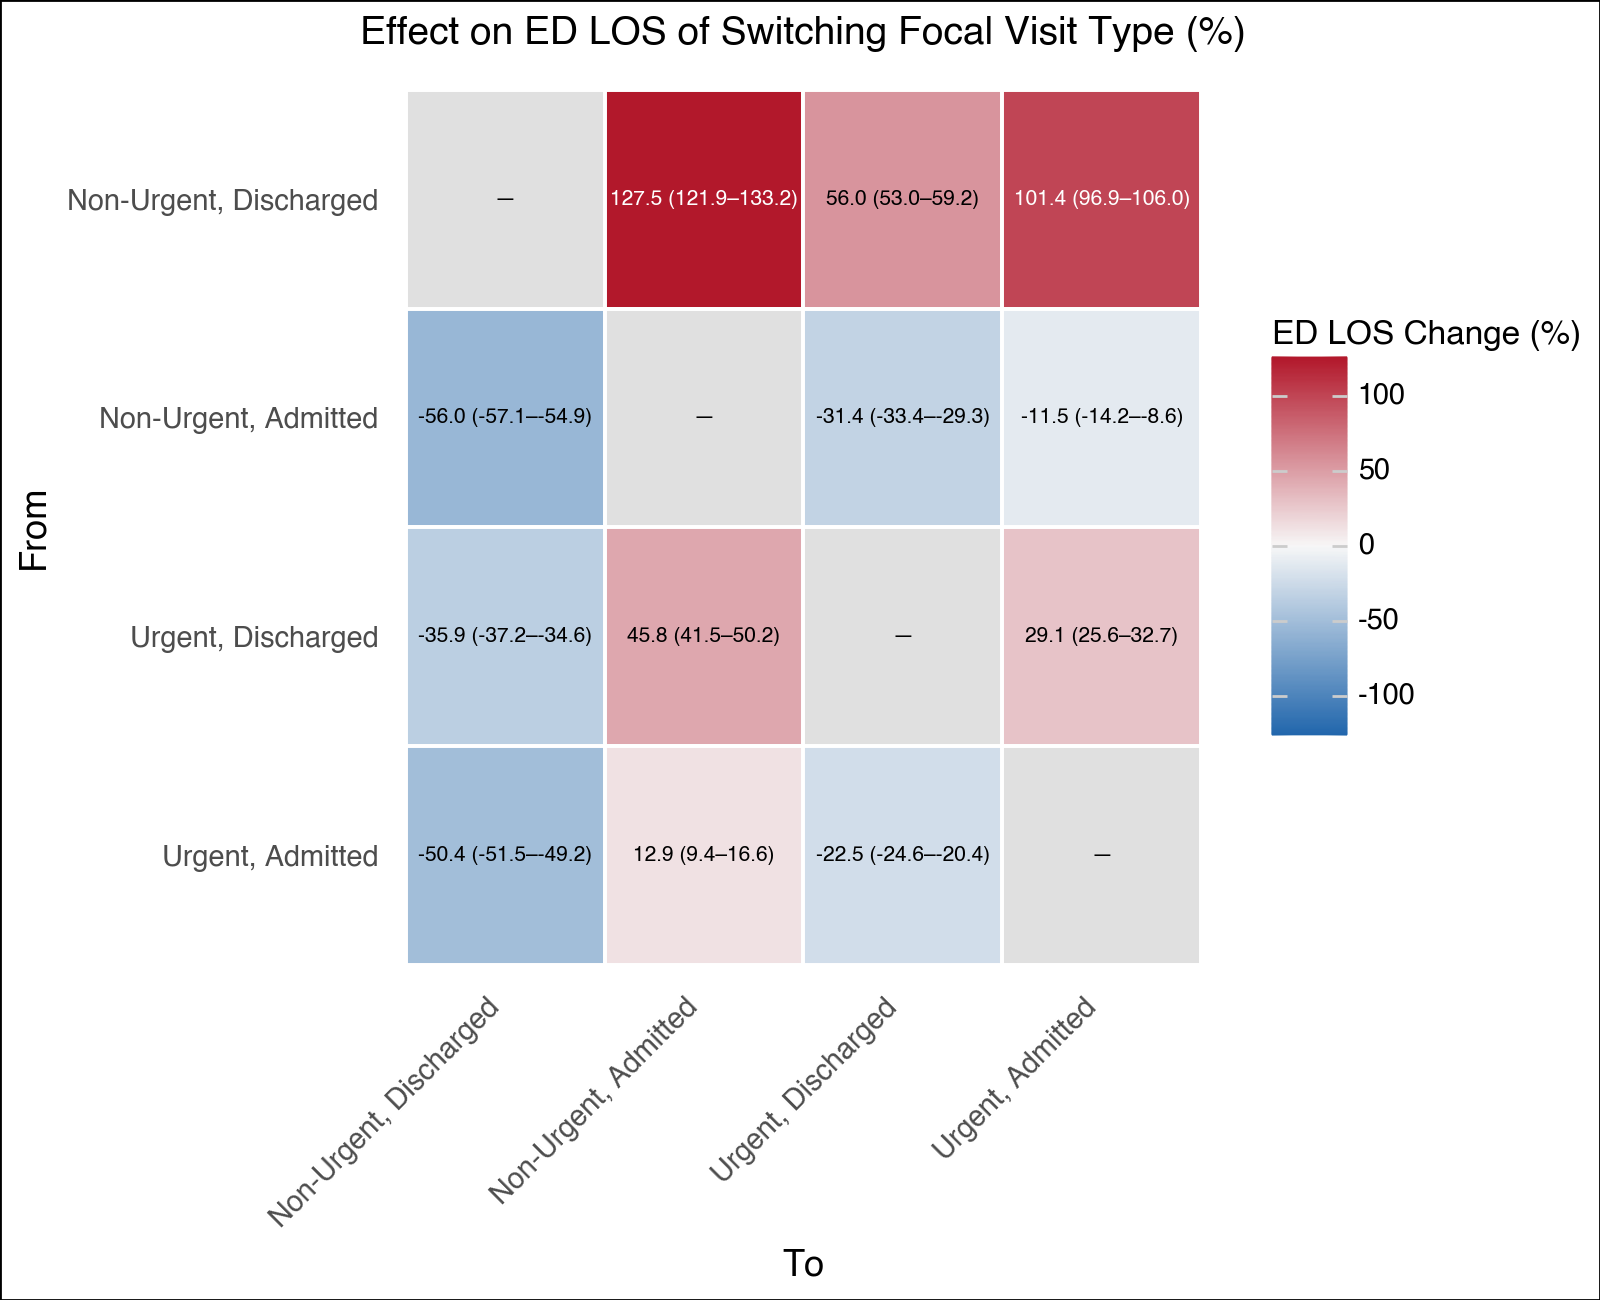

In [18]:
ORDER = ['Non-Urgent, Discharged', 'Non-Urgent, Admitted', 'Urgent, Discharged', 'Urgent, Admitted']

p_switch = plot_annotated_heatmap(
    switching_effects, index_col='from', columns_col='to',
    value_col='ED LOS Change [Est.]', annot_col='ED LOS Change (%) [95% CI]',
    order=ORDER, title='Effect on ED LOS of Switching Focal Visit Type (%)',
    save_path=save_filepath + '/outputs/fig_switching_effects.pdf'
)
p_switch



/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_89669/1349120234.py:100: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
/opt/anaconda3/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8 x 6.5 in image.
/opt/anaconda3/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /Users/helenacoggan/mnt/chip-lacava-e2/Groups/ch265493/BCH-ED/decompensation//outputs/fig_crowding_effects.pdf


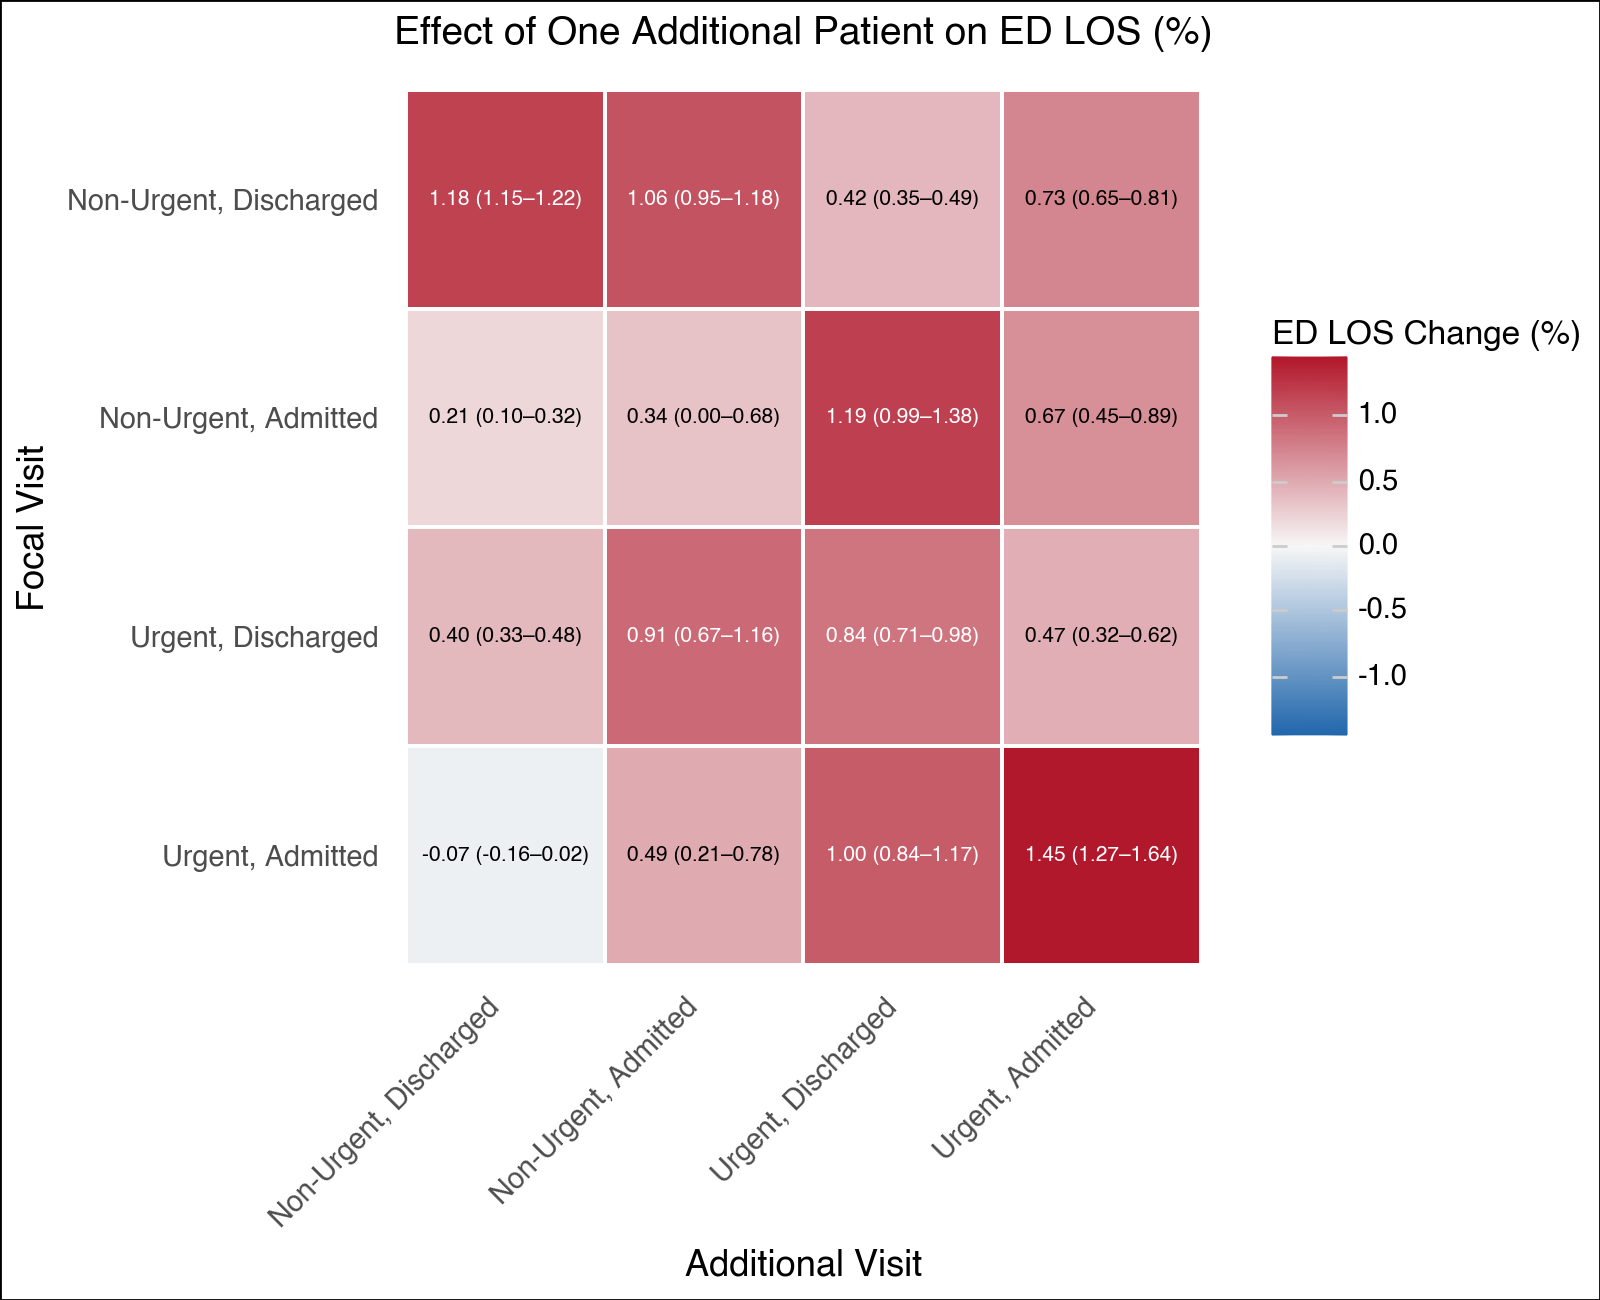

In [19]:

p_crowd = plot_annotated_heatmap(
    crowding_effects, index_col='visit_type', columns_col='crowding_type',
    value_col='ED LOS Change [Est.]', annot_col='ED LOS Change (%) [95% CI]',
    order=ORDER, title='Effect of One Additional Patient on ED LOS (%)', ylab='Focal Visit', xlab='Additional Visit',
    save_path=save_filepath + '/outputs/fig_crowding_effects.pdf'
)
p_crowd

In [20]:
def pivot_to_latex(df, index_col, columns_col, annot_col, order,
                    caption, label, save_path=None):
    """
    Builds a LaTeX booktabs table from the long-form results, with a
    consistent category order and readable dashes for missing/diagonal cells.
    """
    wide = df.pivot(index=index_col, columns=columns_col, values=annot_col)
    wide = wide.reindex(index=order, columns=order)
    wide = wide.fillna('---')

    # ASCII-safe dash for LaTeX (avoids needing inputenc/xelatex for \u2013)
    wide = wide.apply(lambda col: col.astype(str).str.replace('\u2013', '--', regex=False))

    latex = wide.to_latex(
        escape=True,
        column_format='l' + 'c' * len(wide.columns),
        caption=caption,
        label=label,
        na_rep='---'
    )

    if save_path:
        with open(save_path, 'w') as f:
            f.write(latex)
    return latex


switching_latex = pivot_to_latex(
    switching_effects, index_col='from', columns_col='to', annot_col='ED LOS Change (%) [95% CI]',
    order=ORDER, caption='Effect on ED LOS of switching focal visit type (\\% change, 95\\% CI).',
    label='tab:switching-effects',
    save_path=save_filepath + '/outputs/table_switching_effects.tex'
)
print(switching_latex)

crowding_latex = pivot_to_latex(
    crowding_effects, index_col='visit_type', columns_col='crowding_type', annot_col='ED LOS Change (%) [95% CI]',
    order=ORDER, caption='Effect of one additional patient in each crowding category on ED LOS (\\% change, 95\\% CI).',
    label='tab:crowding-effects',
    save_path=save_filepath + '/outputs/table_crowding_effects.tex'
)
print(crowding_latex)

\begin{table}
\caption{Effect on ED LOS of switching focal visit type (\% change, 95\% CI).}
\label{tab:switching-effects}
\begin{tabular}{lcccc}
\toprule
to & Non-Urgent, Discharged & Non-Urgent, Admitted & Urgent, Discharged & Urgent, Admitted \\
from &  &  &  &  \\
\midrule
Non-Urgent, Discharged & --- & 127.5 (121.9--133.2) & 56.0 (53.0--59.2) & 101.4 (96.9--106.0) \\
Non-Urgent, Admitted & -56.0 (-57.1---54.9) & --- & -31.4 (-33.4---29.3) & -11.5 (-14.2---8.6) \\
Urgent, Discharged & -35.9 (-37.2---34.6) & 45.8 (41.5--50.2) & --- & 29.1 (25.6--32.7) \\
Urgent, Admitted & -50.4 (-51.5---49.2) & 12.9 (9.4--16.6) & -22.5 (-24.6---20.4) & --- \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}
\caption{Effect of one additional patient in each crowding category on ED LOS (\% change, 95\% CI).}
\label{tab:crowding-effects}
\begin{tabular}{lcccc}
\toprule
crowding_type & Non-Urgent, Discharged & Non-Urgent, Admitted & Urgent, Discharged & Urgent, Admitted \\
visit_type &  &  &  &  \\

In [21]:
# Now run this for, say, 100 seeds per threshold.
#Identify useful thresholds- we want a good spread of sensitivity values.
#Compute sensivity at each threshold of interest.
def compute_sensitivity(test_df, with_specificity=False):
    test_thresholds = np.linspace(0, 1, num=1001)
    y_prob, y_true = test_df['y_proba'].values, test_df['y_true'].values
    preds_pos = y_prob[:, None] >= test_thresholds[None, :]
    tp = (preds_pos & y_true[:, None]).sum(axis=0)
    fn = (~preds_pos & y_true[:, None]).sum(axis=0)
    tn = (~preds_pos & ~y_true[:, None]).sum(axis=0)
    fp = (preds_pos & ~y_true[:, None]).sum(axis=0)
    sens = tp/(tp+fn)
    spec = tn/(tn+fp)
    
    thresholds_to_keep, sens_to_keep, spec_to_keep = [], [], []

    for sens_aim in np.linspace(0, 1, num=101):
        index = np.argmin(np.abs(sens-sens_aim)) 
        thresholds_to_keep.append(test_thresholds[index])
        sens_to_keep.append(sens[index])
        spec_to_keep.append(spec[index])

    if with_specificity:
        return pd.DataFrame({'Threshold':thresholds_to_keep, 'Sensitivity':sens_to_keep, 'Specificity':spec_to_keep})
    else:
        return pd.DataFrame({'Threshold':thresholds_to_keep, 'Sensitivity':sens_to_keep})

Simulate the deployment of the model.

In [22]:
import heapq
from itertools import product

import joblib
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# Load in switching/crowding effects and baseline model. 
# ---------------------------------------------------------------------------
model = sm.load("ed-los-model.pkl")
visit_timeline = pd.read_csv(save_filepath + 'visit-timeline.csv', index_col=0)

[X_train, X_test, y_train, y_test, csn_train, csn_test] = joblib.load(save_filepath + "outputs/split.joblib")
start_timestamp = visit_timeline.merge(csn_train, on='csn', how='inner')['arrival'].max()

VISIT_TYPES = ['non-urgent-discharged', 'urgent-admitted', 'urgent-discharged', 'non-urgent-admitted']
REF_VISIT_TYPE = 'non-urgent-admitted'  # reference category: no dummy or interaction terms exist for this level


# ---------------------------------------------------------------------------
# ONE-TIME model preprocessing.
# ---------------------------------------------------------------------------
def precompute_model_terms(model, crowding_types=VISIT_TYPES, ref_visit_type=REF_VISIT_TYPE):
    """
    Extract everything `generate_new_ed_los_fast` needs out of the fitted
    statsmodels results object, ONCE, so that per-visit code never touches
    `model` (or pandas) again.

    Parameters
    ----------
    model : statsmodels regression results object
        The fitted OLS model with `log_ed_los` as the outcome, using the
        `C(visit_type)[T....]` / `C(visit_type)[...]:Q('...')` naming
        convention from the model formula (visit-type main effects, plus a
        visit-type x crowding-count interaction for every visit type
        including the reference level -- see the note on
        `ref_visit_type` below).
    crowding_types : list of str, optional
        The set of visit types used as crowding "buckets" -- i.e. the
        `k` in each `Q('k')` interaction term. Defaults to the
        module-level `VISIT_TYPES`. Assumed to be the SAME list as the
        visit types a patient can be assigned to (so every visit type is
        also a crowding bucket).
    ref_visit_type : str, optional
        The reference level of `C(visit_type)`, which has no standalone
        main-effect dummy (`patsy`/`statsmodels` drop it to avoid
        collinearity with the intercept). It still has its own set of
        `C(visit_type)[ref]:Q('k')` interaction terms, since those are
        fit for every level, including the reference one.

    Returns
    -------
    terms : dict
        A small, cheaply-picklable bundle of arrays/maps, safe to pass
        into `joblib.Parallel` workers instead of the full `model` object:

        - "beta" : np.ndarray, shape (P,)
              Model coefficients, `model.params.values`, in the model's
              own parameter order.
        - "cov" : np.ndarray, shape (P, P)
              Full coefficient covariance matrix, `model.cov_params()`,
              aligned to the same parameter order as "beta". Computed
              exactly once here.
        - "P" : int
              Number of model parameters (`len(beta)`), i.e. the length
              of the dense state vectors `_state_vector` builds.
        - "main_idx" : dict[str, int]
              Maps each visit type to the integer position (into "beta"
              and "cov") of its `C(visit_type)[T.<visit_type>]` main
              effect. Maps to -1 for `ref_visit_type`, which has no such
              coefficient -- callers must check for -1 before indexing.
        - "interact_idx" : dict[str, np.ndarray]
              Maps each visit type to an integer array of length
              `len(crowding_types)`, giving the position (into "beta" and
              "cov") of that visit type's `C(visit_type)[vt]:Q('k')`
              interaction coefficient for each crowding bucket `k`, in
              the same order as `crowding_types`. Every visit type
              (including the reference one) has a full set of these.
    """
    param_names = list(model.params.index)
    name_to_idx = {name: i for i, name in enumerate(param_names)}
    beta = model.params.values.astype(float)
    cov = model.cov_params().values.astype(float)  # computed ONCE, not per-visit

    main_idx = {}
    interact_idx = {}
    for vt in crowding_types:
        # -1 marks the reference visit type, which has no main-effect dummy.
        main_idx[vt] = name_to_idx.get(f"C(visit_type)[T.{vt}]", -1)
        interact_idx[vt] = np.array(
            [name_to_idx[f"C(visit_type)[{vt}]:Q('{k}')"] for k in crowding_types],
            dtype=int,
        )

    return {
        "beta": beta,
        "cov": cov,
        "P": len(param_names), #Includes both solo and interaction terms
        "main_idx": main_idx, #Links main terms to indices
        "interact_idx": interact_idx, #Links interaction terms to indices
    }


def _state_vector(visit_type, crowding_counts, terms):
    """
    Build the dense length-P parameter-multiplier vector for ONE state
    (one visit_type + one set of crowding counts), i.e. the numpy
    equivalent of what `_build_param_vector` returned as a sparse dict of
    `{param_name: multiplier}` in the original code.

    Concretely, for state `(visit_type, crowding_counts)`, this returns a
    vector `vec` of length `terms["P"]` such that `vec @ terms["beta"]`
    is that state's contribution to the linear predictor:

        vec[terms["main_idx"][visit_type]]        = 1                     (if visit_type != ref)
        vec[terms["interact_idx"][visit_type][j]] = crowding_counts[j]    (for every crowding bucket j)
        vec[everything else]                       = 0

    Two states' vectors can then be subtracted (`vec_new - vec_old`) to
    get the linear contrast used for the "switching + crowding" effect,
    exactly as `generate_new_ed_los`'s `contrast` did -- just as a dense
    numpy array indexed by integer position instead of a `pd.Series`
    indexed by coefficient name.

    Parameters
    ----------
    visit_type : str
        The visit type for this state (must be a key of both
        `terms["main_idx"]` and `terms["interact_idx"]`).
    crowding_counts : array-like of float, length len(crowding_types)
        Crowding bucket counts for this state, in the same bucket order
        used when `terms` was built (i.e. aligned with `VISIT_TYPES`).
        Assigned into `vec` via `terms["interact_idx"][visit_type]`, so
        `crowding_counts[j]` lands on the coefficient for bucket `j`.
    terms : dict
        The bundle returned by `precompute_model_terms`.

    Returns
    -------
    vec : np.ndarray, shape (terms["P"],)
        Dense parameter-multiplier vector for this state. Mostly zeros --
        only the `len(crowding_counts)` interaction entries (and, for
        non-reference visit types, one main-effect entry) are nonzero.
    """
    vec = np.zeros(terms["P"]) #of length P
    vec[terms["interact_idx"][visit_type]] = crowding_counts #Finds the index of the crowding-counts term
    mi = terms["main_idx"][visit_type] #Finds the index of the visit_type term
    if mi != -1:
        vec[mi] = 1.0
    return vec


def generate_new_ed_los_fast(terms, old_ed_los, new_visit_type, new_crowding_counts,
                              old_visit_type, old_crowding_counts, z_sample):

    vec_old = _state_vector(old_visit_type, old_crowding_counts, terms)
    vec_new = _state_vector(new_visit_type, new_crowding_counts, terms)
    contrast = vec_new - vec_old

    beta, cov = terms["beta"], terms["cov"]
    log_diff = contrast @ beta
    var_diff = contrast @ cov @ contrast
    se_diff = np.sqrt(max(var_diff, 0.0))

    log_delta_sample = log_diff + se_diff * z_sample
    new_ed_los = old_ed_los * np.exp(log_delta_sample)
    return new_ed_los, log_diff, se_diff


# ---------------------------------------------------------------------------
# Heap-based crowding update.
#
# ---------------------------------------------------------------------------
def simulate_ed_los_changes_fast(
    terms,
    arrival_times,
    departure_times,
    old_visit_types,
    new_visit_types,
    old_crowding_states,
    old_ed_los_times,
    VISIT_TYPES=VISIT_TYPES,
    ref_visit_type=REF_VISIT_TYPE,
    simulation_start_time=0,
    rng=None,
):
    if rng is None:
        rng = np.random.default_rng()

    vt_index = {vt: i for i, vt in enumerate(VISIT_TYPES)}

    last_change_index = np.argmin(
        np.where(arrival_times <= simulation_start_time, simulation_start_time - arrival_times, np.inf)
    )
    current_crowding_state = old_crowding_states[:, last_change_index].copy().astype(float)

    arrival_index = np.argmin(
        np.where(arrival_times >= simulation_start_time, arrival_times - simulation_start_time, np.inf)
    )
    first_arrival = arrival_times[arrival_index]

    # Seed the heap with everyone already in the ED at simulation start --
    # exactly the people already counted in current_crowding_state.
    still_in_ed = np.where(
        (arrival_times <= simulation_start_time) & (departure_times > first_arrival)
    )[0]
    heap = [(departure_times[i], vt_index[new_visit_types[i]]) for i in still_in_ed]
    heapq.heapify(heap)

    # Pre-draw all the standard-normal shocks for this run in one call
    # instead of one rng.normal(...) call per visit.
    n_remaining = len(arrival_times) - arrival_index
    z_samples = rng.standard_normal(n_remaining)
    z_pos = 0

    while arrival_index < len(arrival_times):
        arrival = arrival_times[arrival_index]
        old_visit_type = old_visit_types[arrival_index]
        new_visit_type = new_visit_types[arrival_index]
        old_ed_los = old_ed_los_times[arrival_index]
        old_crowding = old_crowding_states[:, arrival_index]

        # Pop everyone who has departed by `arrival` off the heap.
        while heap and heap[0][0] <= arrival:
            _, vt_i = heapq.heappop(heap)
            current_crowding_state[vt_i] -= 1

        current_crowding_state[vt_index[new_visit_type]] += 1

        new_ed_los, _, _ = generate_new_ed_los_fast(
            terms, old_ed_los, new_visit_type, current_crowding_state,
            old_visit_type, old_crowding, z_samples[z_pos],
        )
        z_pos += 1

        new_departure = arrival + new_ed_los
        departure_times[arrival_index] = new_departure
        heapq.heappush(heap, (new_departure, vt_index[new_visit_type]))

        arrival_index += 1

    return departure_times


# ---------------------------------------------------------------------------
# SIMULATE DEPLOYMENT (unchanged logic, just wired to the fast functions)
# ---------------------------------------------------------------------------
test_df = pd.read_csv(save_filepath + "outputs/test-preds.csv", index_col=0)
visit_timeline = visit_timeline.merge(test_df[['csn', 'y_proba', 'y_true']], on='csn', how='left').sort_values('arrival')


def simulate_uptriage(visit_timeline, threshold):
    sim_vts = visit_timeline.copy()
    probs = sim_vts['y_proba'].values
    uptriages = ((~np.isnan(probs)) & (probs >= threshold))
    sim_vts['urgent'] = np.where(uptriages, 1, sim_vts['urgent'])
    new_visit_types = np.where(
        uptriages,
        np.where(sim_vts['visit_type'] == 'non-urgent-admitted', 'urgent-admitted', 'urgent-discharged'),
        sim_vts['visit_type'],
    )
    return new_visit_types


MODEL_TERMS = precompute_model_terms(model, crowding_types=VISIT_TYPES, ref_visit_type=REF_VISIT_TYPE)


def run_simulation_fast(visit_timeline, threshold, terms=MODEL_TERMS, seed=210226, bootstrap_resamples=500):
    """
    Runs one (threshold, seed) simulation AND immediately collapses it down
    to per-seed summary rows before returning, instead of returning one row
    per visit.
    """
    rng = np.random.default_rng(seed=seed)

    # The heap walk (like the original window scan) assumes row i, i+1,
    # i+2, ... are in non-decreasing arrival-time order. visit_timeline is
    # aligned by csn, not guaranteed to already be arrival-ordered, so we
    # sort explicitly here and undo the permutation before returning --
    # rather than silently relying on the input already being sorted.
    order = np.argsort(visit_timeline['arrival'].values, kind='stable')
    inverse_order = np.argsort(order)  # maps sorted-position -> original row

    vt_sorted = visit_timeline.iloc[order]
    arrival_times = vt_sorted['arrival'].values
    old_ed_los = vt_sorted['ed_los'].values
    departure_times = (arrival_times + old_ed_los).copy()
    old_crowding_states = np.array([vt_sorted[vtype].values for vtype in VISIT_TYPES])
    old_visit_types = vt_sorted['visit_type'].values

    new_visit_types = simulate_uptriage(vt_sorted, threshold)

    new_departure_times_sorted = simulate_ed_los_changes_fast(
        terms,
        arrival_times,
        departure_times,
        old_visit_types,
        new_visit_types,
        old_crowding_states,
        old_ed_los,
        VISIT_TYPES=VISIT_TYPES,
        ref_visit_type=REF_VISIT_TYPE,
        simulation_start_time=start_timestamp,
        rng=rng,
    )

    # Build the per-visit result table -- but ONLY within this worker's
    # local scope. It's used immediately below to compute summary
    # statistics and is never returned or concatenated across runs.
    per_visit = pd.DataFrame({
        'old_visit_type': old_visit_types,
        'new_visit_type': new_visit_types,
        'arrival': arrival_times,
        'old_ed_los': old_ed_los,
        'new_ed_los': new_departure_times_sorted - arrival_times,
    })
    per_visit['change_in_ed_los'] = per_visit['new_ed_los'] - per_visit['old_ed_los']
    per_visit['frac_change_in_ed_los'] = per_visit['new_ed_los']/per_visit['old_ed_los'] - 1
    per_visit['sim_prolonged_stay'] = (per_visit['new_ed_los'] > 8 * 60).astype(int)

    #ONLY COUNT RESULTS AMONGST PEOPLE WHO ARRIVED AFTER THE START TIME.
    per_visit = per_visit[per_visit['arrival'] >= start_timestamp].copy()

    #Return both mean and standard deviation (avoids bootstrapping costs)
    def summary_row(df, group_type, group_value):
        return {
            'Threshold': threshold, 'seed': seed,
            'group_type': group_type, 'group_value': group_value, 'n': len(df),
            'new_ed_los': df['new_ed_los'].mean(),
            'sd_new_ed_los': df['new_ed_los'].std(ddof=1),
            'change_in_ed_los': df['change_in_ed_los'].mean(),
            'sd_change_in_ed_los': df['change_in_ed_los'].std(ddof=1),
            'frac_change_in_ed_los': df['frac_change_in_ed_los'].mean(),
            'sd_frac_change_in_ed_los': df['frac_change_in_ed_los'].std(ddof=1),
            'prolonged_stay': df['sim_prolonged_stay'].mean(),
            'sd_prolonged_stay': df['sim_prolonged_stay'].std(ddof=1),
        }
 
    rows = [summary_row(per_visit, 'overall', 'overall')]
    for vt, g in per_visit.groupby('old_visit_type'):
        rows.append(summary_row(g, 'old_visit_type', vt))
    for vt, g in per_visit.groupby('new_visit_type'):
        rows.append(summary_row(g, 'new_visit_type', vt))
 
    return pd.DataFrame(rows)




sensitivity_df = compute_sensitivity(test_df)
seeds = list(range(1, 101))
params_to_test = list(product(sensitivity_df['Threshold'].unique(), seeds))

# NOTE: we pass MODEL_TERMS (a small dict of numpy arrays) into each
# parallel task instead of the full statsmodels `model` object, to avoid
# re-pickling the whole fitted model 2,020 times. Each task now returns a
# handful of summary rows (not one row per visit).
run_summaries = joblib.Parallel(n_jobs=12, verbose=1)(
    joblib.delayed(run_simulation_fast)(visit_timeline, threshold, MODEL_TERMS, seed=seed)
    for [threshold, seed] in params_to_test
)

# Each row here is already a per-(Threshold, seed, group) summary.
run_summaries = pd.concat(run_summaries, ignore_index=True)
run_summaries.to_csv(save_filepath+'outputs/run-summaries.csv')
sensitivity_df.to_csv(save_filepath+'outputs/sensitivity_df.csv')


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    5.2s
/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the e

In [27]:
#Combine standard deviations within and across seeds for each metric.
def aggregate_across_seeds(run_summaries, group_type, include_within_seed_variation=False):
    """
    Combines the two sources of uncertainty in run_summaries into one SD
    per (Threshold, group), via the law of total variance:
 
        Var(total) = E_seed[ Var(mean | seed) ] + Var_seed( mean )

    """
    subset = run_summaries[run_summaries['group_type'] == group_type].copy()
    group_cols = ['Threshold'] if group_type == 'overall' else ['Threshold', 'group_value']
 
    metrics = ['new_ed_los', 'change_in_ed_los', 'frac_change_in_ed_los', 'prolonged_stay']
    for m in metrics:
        subset[f'_within_seed_var_{m}'] = subset[f'sd_{m}'] ** 2 
 
    agg_spec = {}
    for m in metrics:
        agg_spec[f'mean_{m}'] = (m, 'mean')                              # grand mean across seeds
        agg_spec[f'_between_seed_var_{m}'] = (m, 'var')                  # ddof=1 by default
        agg_spec[f'_within_seed_var_{m}'] = (f'_within_seed_var_{m}', 'mean')
 
    result = subset.groupby(group_cols).agg(**agg_spec).reset_index()
 
    for m in metrics:
        if include_within_seed_variation:
            total_var = result[f'_between_seed_var_{m}'] + result[f'_within_seed_var_{m}']
        else:
            total_var = result[f'_between_seed_var_{m}'] 
        result[f'sd_{m}'] = np.sqrt(total_var)
 
    return result
 
 
overall_results = aggregate_across_seeds(run_summaries, 'overall')
results_by_old_type = aggregate_across_seeds(run_summaries, 'old_visit_type').rename(
    columns={'group_value': 'old_visit_type'})
results_by_new_type = aggregate_across_seeds(run_summaries, 'new_visit_type').rename(
    columns={'group_value': 'new_visit_type'})
 
 
overall_results.to_csv(save_filepath+"outputs/overall-sim-results.csv")
results_by_old_type.to_csv(save_filepath+"outputs/sim-results-by-original-visit-type.csv")
results_by_new_type.to_csv(save_filepath+"outputs/sim-results-by-new-visit-type.csv")
 

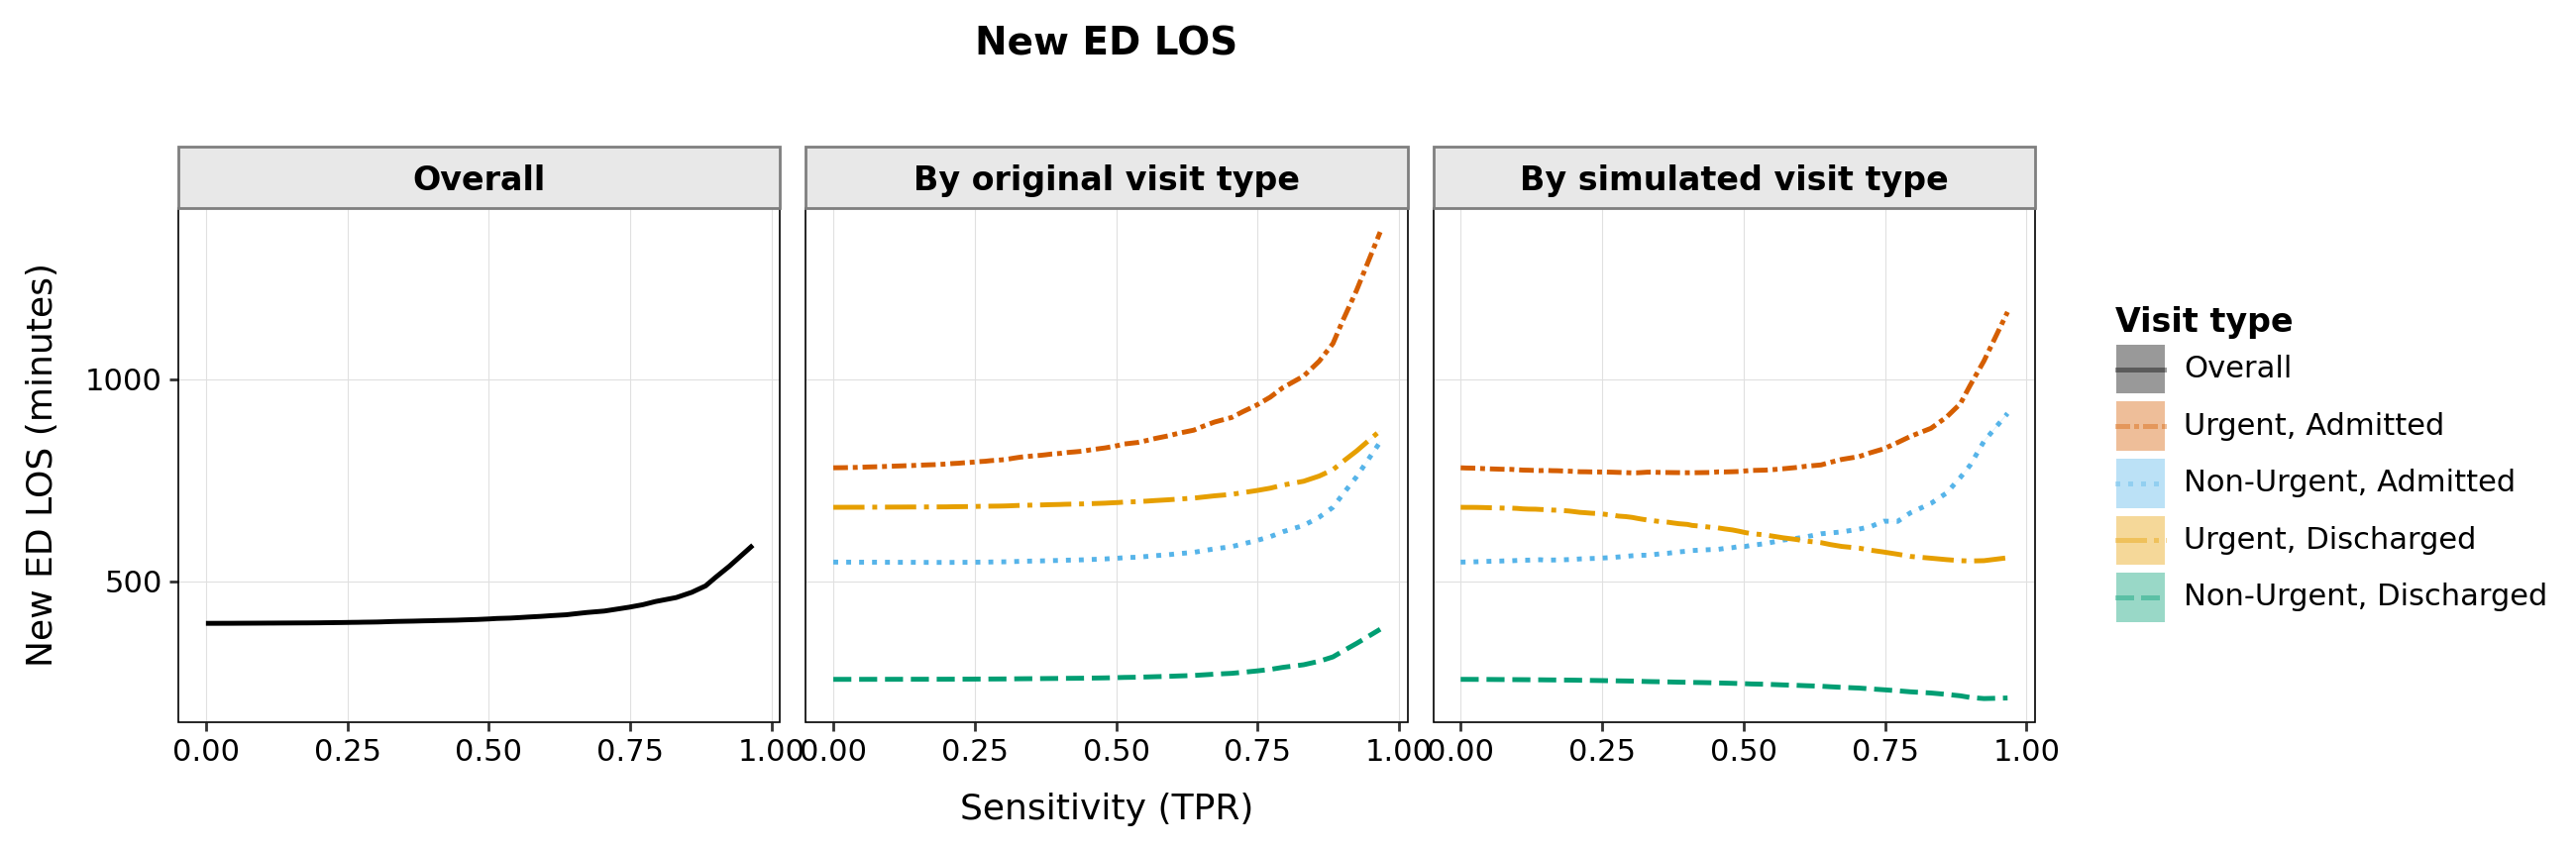

Saved /Users/helenacoggan/mnt/chip-lacava-e2/Groups/ch265493/BCH-ED/decompensation/outputs/plot-mean_new_ed_los.pdf and /Users/helenacoggan/mnt/chip-lacava-e2/Groups/ch265493/BCH-ED/decompensation/outputs/plot-mean_new_ed_los.png


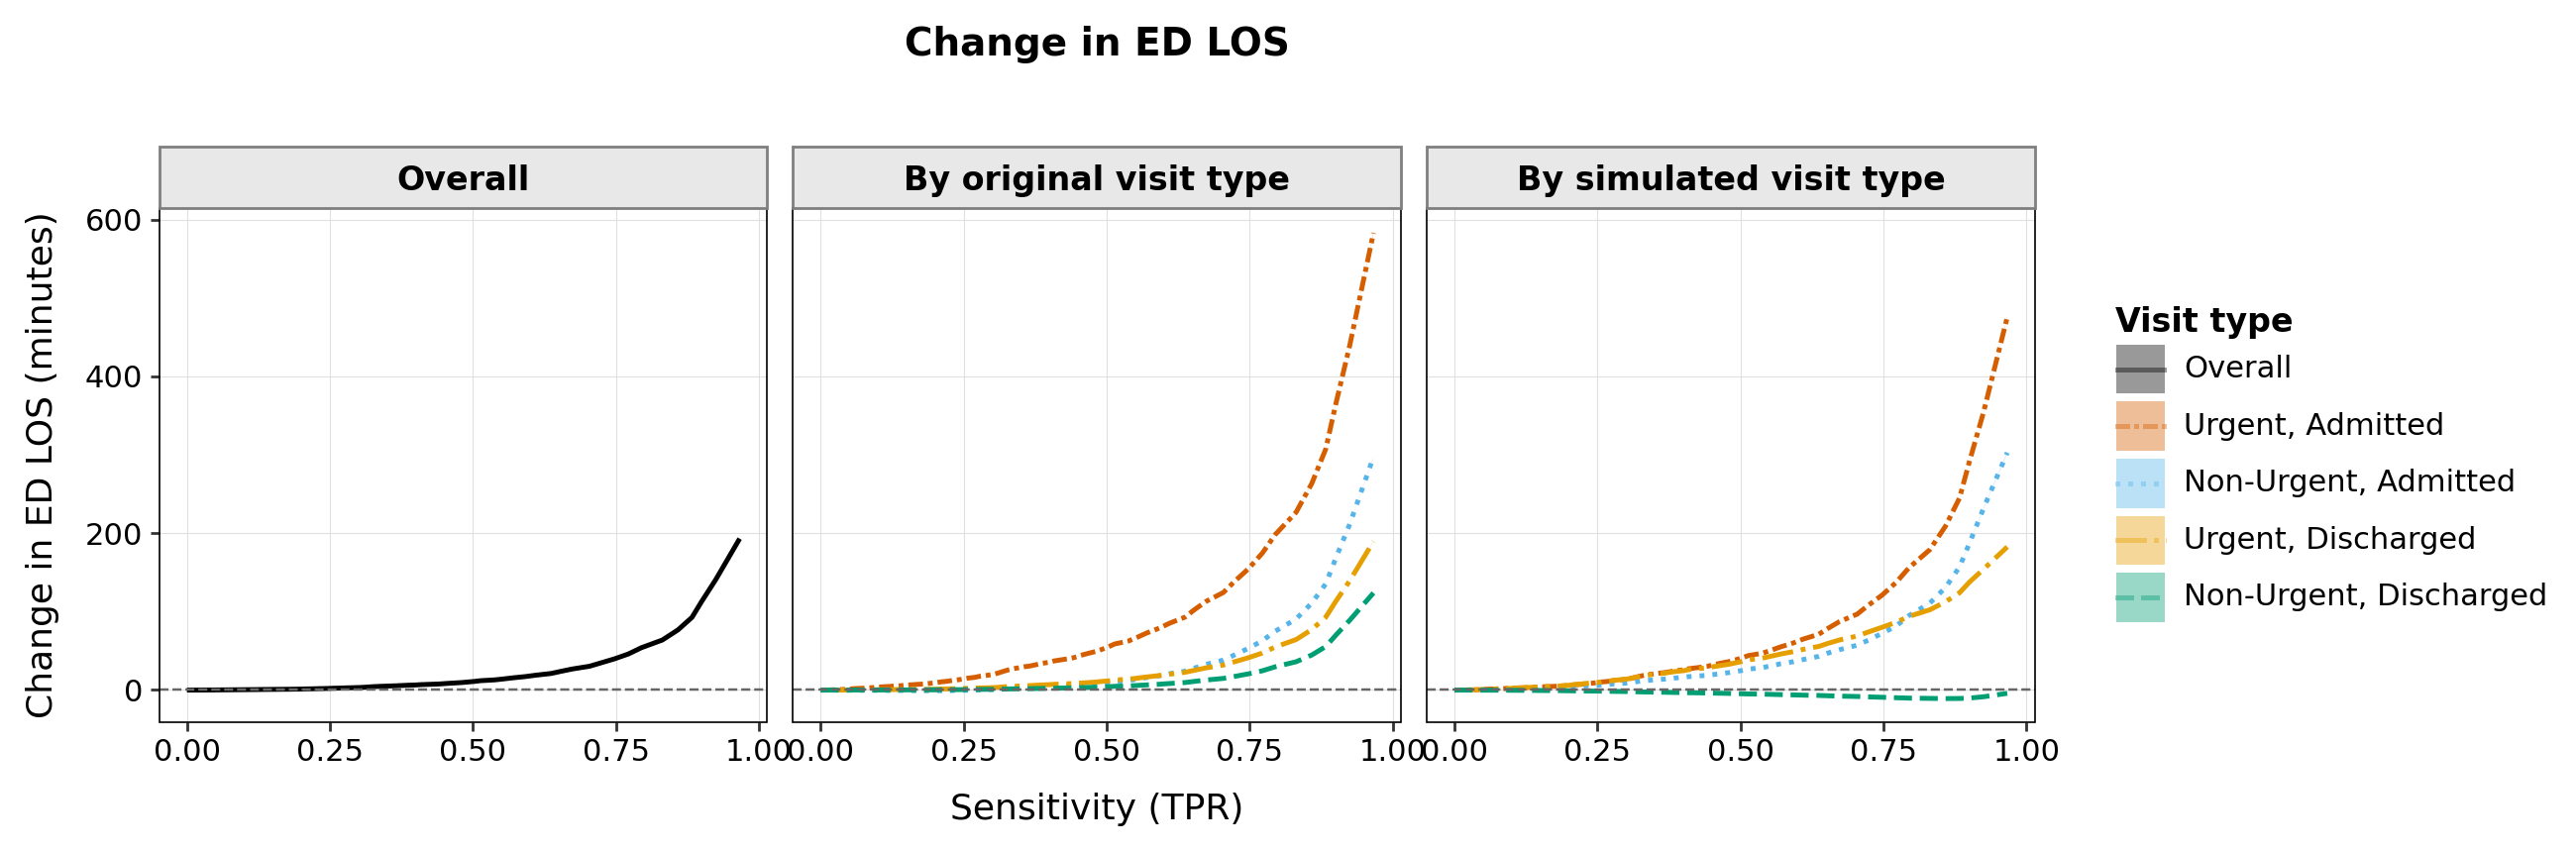

Saved /Users/helenacoggan/mnt/chip-lacava-e2/Groups/ch265493/BCH-ED/decompensation/outputs/plot-mean_change_in_ed_los.pdf and /Users/helenacoggan/mnt/chip-lacava-e2/Groups/ch265493/BCH-ED/decompensation/outputs/plot-mean_change_in_ed_los.png


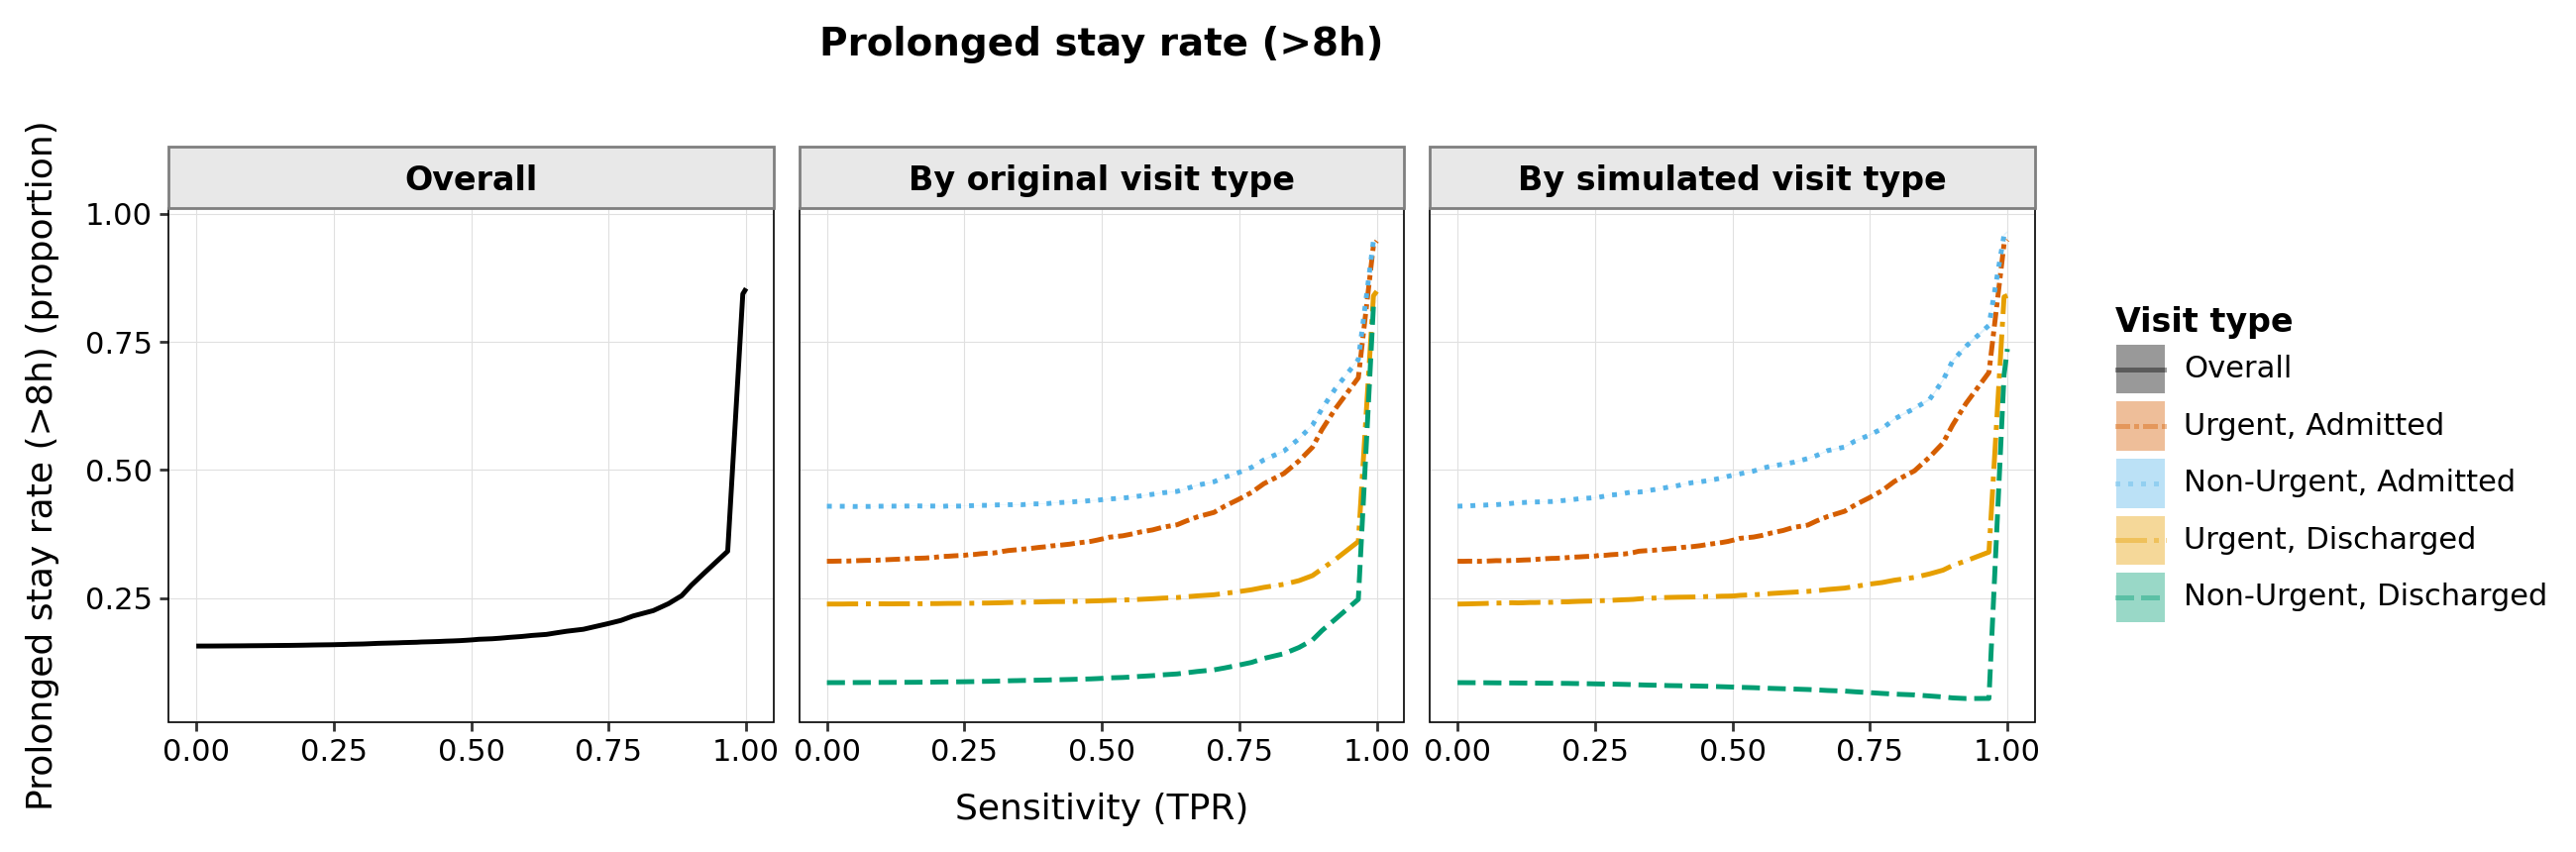

Saved /Users/helenacoggan/mnt/chip-lacava-e2/Groups/ch265493/BCH-ED/decompensation/outputs/plot-mean_prolonged_stay.pdf and /Users/helenacoggan/mnt/chip-lacava-e2/Groups/ch265493/BCH-ED/decompensation/outputs/plot-mean_prolonged_stay.png


In [28]:
"""
Publication-ready ribbon plots of the ED-LOS simulation metrics vs.
uptriage sensitivity (TPR), using plotnine.

Loads results fresh from disk (not from in-memory objects), so this is
runnable standalone any time after the simulation has written its CSVs.
For each headline metric, draws one faceted figure -- Overall / by original
visit type / by simulated visit type -- with a mean line and a shaded
ribbon at +/- 1 SD (patient-level total spread; see aggregate_across_seeds
in the simulation script for what that SD combines).

Figures are saved as both PDF (vector, for print/journal submission) and
PNG (for previews, slides, presentations) at 300 DPI.
"""
import numpy as np
import pandas as pd
from plotnine import (
    ggplot, aes, geom_line, geom_ribbon, geom_hline, facet_wrap,
    labs, theme_bw, theme, element_text, element_rect, element_line, element_blank,
    scale_color_manual, scale_fill_manual, scale_linetype_manual, guides, guide_legend,
)

# ---------------------------------------------------------------------------
# 1) Load results from disk.
# ---------------------------------------------------------------------------
overall_results = pd.read_csv(save_filepath + "outputs/overall-sim-results.csv", index_col=0)
results_by_old_type = pd.read_csv(save_filepath + "outputs/sim-results-by-original-visit-type.csv", index_col=0)
results_by_new_type = pd.read_csv(save_filepath + "outputs/sim-results-by-new-visit-type.csv", index_col=0)
sensitivity_df = pd.read_csv(save_filepath + 'outputs/sensitivity_df.csv', index_col=0)

# (mean column, sd column, display title, y-axis units) for each metric.
METRICS = [
    ("mean_new_ed_los", "sd_new_ed_los", "New ED LOS", "minutes", None),
    ("mean_change_in_ed_los", "sd_change_in_ed_los", "Change in ED LOS", "minutes", None),
    ("mean_prolonged_stay", "sd_prolonged_stay", "Prolonged stay rate (>8h)", "proportion", (0, 1)),
]

PANEL_ORDER = ["Overall", "By original visit type", "By simulated visit type"]
GROUP_NAME_MAP = {"Overall": "Overall", 'urgent-admitted': "Urgent, Admitted", 'non-urgent-admitted': "Non-Urgent, Admitted",
                   'urgent-discharged': "Urgent, Discharged", 'non-urgent-discharged': "Non-Urgent, Discharged"}

# Full Okabe-Ito colorblind-safe palette (verified distinguishable under
# deuteranopia, protanopia, and tritanopia). The previous palette's neon
# green (#39FF14) wasn't part of this set and read as an outlier/mistake
# next to the rest -- replaced with Okabe-Ito's bluish green. 'Overall' is
# black so it reads as the neutral aggregate rather than a fifth competing
# hue.
GROUP_COLORS = {
    "Overall": "#000000",
    "Non-Urgent, Discharged": "#009E73",  # bluish green
    "Non-Urgent, Admitted": "#56B4E9",    # sky blue
    "Urgent, Discharged": "#E69F00",      # orange
    "Urgent, Admitted": "#D55E00",        # vermillion
}

# Linetype is a SECOND, independent encoding of the same grouping -- lines
# stay distinguishable in grayscale printing, on a projector with poor
# color fidelity, or for readers with color vision deficiency, even if
# color alone were ambiguous. Combined with scale_*_manual sharing the same
# name="Visit type", plotnine merges these into ONE legend (each key shows
# both the color swatch and the line's dash pattern) rather than two
# separate legends.
GROUP_LINETYPES = {
    "Overall": "solid",
    "Non-Urgent, Discharged": "dashed",
    "Non-Urgent, Admitted": "dotted",
    "Urgent, Discharged": "dashdot",
    "Urgent, Admitted": (0, (3, 1, 1, 1)),  # dash-dot-dot: visually distinct from the other four
}

FONT = "DejaVu Sans"  # widely available; swap for a house font if you have one


# ---------------------------------------------------------------------------
# 2) Reshape each metric's three source tables into one tidy long-format
#    DataFrame, and attach Sensitivity (TPR) via the Threshold join.
# ---------------------------------------------------------------------------
def build_long_df(mean_col, sd_col, clip_range=None):
    overall = overall_results[["Threshold", mean_col, sd_col]].copy()
    overall["panel"] = "Overall"
    overall["group"] = "Overall"

    by_old = results_by_old_type[["Threshold", "old_visit_type", mean_col, sd_col]].copy()
    by_old["panel"] = "By original visit type"
    by_old = by_old.rename(columns={"old_visit_type": "group"})

    by_new = results_by_new_type[["Threshold", "new_visit_type", mean_col, sd_col]].copy()
    by_new["panel"] = "By simulated visit type"
    by_new = by_new.rename(columns={"new_visit_type": "group"})

    long_df = pd.concat([overall, by_old, by_new], ignore_index=True)
    long_df = long_df.rename(columns={mean_col: "mean", sd_col: "sd"})
    long_df = long_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["mean", "sd"])

    long_df = long_df.merge(sensitivity_df[["Threshold", "Sensitivity"]], on="Threshold", how="inner")

    long_df["ymin"] = long_df["mean"] - long_df["sd"]
    long_df["ymax"] = long_df["mean"] + long_df["sd"]
    if clip_range is not None:
        # A symmetric mean +/- SD band can otherwise extend past the
        # natural bounds of a bounded quantity (e.g. a proportion going
        # below 0% or above 100%), which reads as an obvious artifact in
        # print. Clip to the metric's valid range; the mean line itself is
        # untouched.
        lo, hi = clip_range
        long_df["ymin"] = long_df["ymin"].clip(lower=lo)
        long_df["ymax"] = long_df["ymax"].clip(upper=hi)
    long_df["panel"] = pd.Categorical(long_df["panel"], categories=PANEL_ORDER, ordered=True)
    long_df["group"] = pd.Categorical(long_df["group"].map(GROUP_NAME_MAP),
                                       categories=list(GROUP_NAME_MAP.values()), ordered=True)
    return long_df.sort_values(["panel", "group", "Sensitivity"])


# ---------------------------------------------------------------------------
# 3) Shared publication theme: larger, print-legible type; a light,
#    minimal grid; a bold but unobtrusive facet strip; a clean legend.
# ---------------------------------------------------------------------------
def publication_theme():
    return theme_bw(base_size=13, base_family=FONT) + theme(
        figure_size=(13, 4.3),
        plot_title=element_text(size=14, weight="bold", margin={"b": 10}),
        axis_title=element_text(size=13),
        axis_text=element_text(size=11, color="black"),
        strip_background=element_rect(fill="#e8e8e8"),
        strip_text=element_text(size=12, weight="bold", color="black"),
        panel_grid_minor=element_blank(),
        panel_grid_major=element_line(color="#e0e0e0", size=0.4),
        panel_border=element_rect(color="black", size=0.6),
        legend_title=element_text(size=12, weight="bold"),
        legend_text=element_text(size=11),
        legend_key=element_blank(),
        legend_position="right",
    )


def plot_metric(mean_col, sd_col, title, units, clip_range=None):
    long_df = build_long_df(mean_col, sd_col, clip_range=clip_range)

    p = (
        ggplot(long_df, aes(x="Sensitivity", y="mean", ymin="ymin", ymax="ymax",
                             color="group", fill="group"))
        + geom_ribbon(alpha=0.18, color="none")
        + geom_line(aes(linetype="group"), size=1.0)
        + facet_wrap("~panel", nrow=1)
        + scale_color_manual(values=GROUP_COLORS, name="Visit type")
        + scale_fill_manual(values=GROUP_COLORS, name="Visit type")
        + scale_linetype_manual(values=GROUP_LINETYPES, name="Visit type")
        + labs(
            title=f"{title}",
            x="Sensitivity (TPR)",
            y=f"{title} ({units})",
        )
        + publication_theme()
        + guides(color=guide_legend(override_aes={"alpha": 0.4}))
    )

    if "change" in mean_col:
        p = p + geom_hline(yintercept=0, linetype="dashed", color="#666666", size=0.5)

    p.show()
    return p


# ---------------------------------------------------------------------------
# 4) Build one figure per metric; save as both vector PDF (for
#    print/journal submission) and 300 DPI PNG (for previews/slides).
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    for mean_col, sd_col, title, units, clip_range in METRICS:
        p = plot_metric(mean_col, sd_col, title, units, clip_range=clip_range)
        base = save_filepath + f"outputs/plot-{mean_col}"
        p.save(f"{base}.pdf", verbose=False)
        p.save(f"{base}.png", dpi=300, verbose=False)
        print(f"Saved {base}.pdf and {base}.png")

In [33]:
#Load results.
test_df = pd.read_csv(save_filepath + "outputs/test-preds.csv", index_col=0)
sensitivity_df = compute_sensitivity(test_df, with_specificity=True)


overall_results = pd.read_csv(save_filepath + "outputs/overall-sim-results.csv", index_col=0).merge(sensitivity_df, on="Threshold", how='inner')
results_by_old_type = pd.read_csv(save_filepath + "outputs/sim-results-by-original-visit-type.csv", index_col=0).merge(sensitivity_df, on="Threshold", how='inner')
results_by_new_type = pd.read_csv(save_filepath + "outputs/sim-results-by-new-visit-type.csv", index_col=0).merge(sensitivity_df, on="Threshold", how='inner')



#What is the highest sensivity at which the model can be used without causing any overall changes?
overall_ed_los_limit = 5

sensitivity_limit = overall_results[overall_results['mean_change_in_ed_los'] < overall_ed_los_limit]['Sensitivity'].max()
overall_results_at_sens_limit = overall_results[overall_results['Sensitivity'] == sensitivity_limit]
groupwise_results_by_new_type = results_by_new_type[results_by_new_type['Sensitivity'] == sensitivity_limit]


groupwise_results_by_new_type

,Threshold,new_visit_type,mean_new_ed_los,_between_seed_var_new_ed_los,_within_seed_var_new_ed_los,mean_change_in_ed_los,_between_seed_var_change_in_ed_los,_within_seed_var_change_in_ed_los,mean_frac_change_in_ed_los,_between_seed_var_frac_change_in_ed_los,_within_seed_var_frac_change_in_ed_los,mean_prolonged_stay,_between_seed_var_prolonged_stay,_within_seed_var_prolonged_stay,sd_new_ed_los,sd_change_in_ed_los,sd_frac_change_in_ed_los,sd_prolonged_stay,Sensitivity,Specificity
224,0.035,non-urgent-admitted,567.165464,0.002169,5.371897e+05,12.734536,0.002169,400.698500,0.022390,3.580309e-09,0.000395,0.459734,2.467546e-07,0.248408,0.046572,0.046572,0.000060,0.000497,0.34588,0.941858
225,0.035,non-urgent-discharged,252.050642,0.000059,4.625686e+04,-2.675539,0.000059,34.342723,-0.009949,6.335920e-10,0.000234,0.080571,2.746665e-09,0.074080,0.007699,0.007699,0.000025,0.000052,0.34588,0.941858
226,0.035,urgent-admitted,769.860560,0.010657,3.673841e+06,20.282511,0.010657,8878.953245,0.021727,4.491406e-09,0.002193,0.342971,1.140652e-07,0.225354,0.103235,0.103235,0.000067,0.000338,0.34588,0.941858
227,0.035,urgent-discharged,649.133738,0.003260,2.375722e+06,19.704755,0.003260,2841.387948,0.053428,2.394236e-09,0.013695,0.249676,4.974111e-08,0.187345,0.057098,0.057098,0.000049,0.000223,0.34588,0.941858


In [34]:
overall_results_at_sens_limit

,Threshold,mean_new_ed_los,_between_seed_var_new_ed_los,_within_seed_var_new_ed_los,mean_change_in_ed_los,_between_seed_var_change_in_ed_los,_within_seed_var_change_in_ed_los,mean_frac_change_in_ed_los,_between_seed_var_frac_change_in_ed_los,_within_seed_var_frac_change_in_ed_los,mean_prolonged_stay,_between_seed_var_prolonged_stay,_within_seed_var_prolonged_stay,sd_new_ed_los,sd_change_in_ed_los,sd_frac_change_in_ed_los,sd_prolonged_stay,Sensitivity,Specificity
56,0.035,401.340754,0.000572,960396.680429,4.879197,0.000572,1705.220777,0.006912,8.389899e-10,0.003502,0.162398,4.248556e-09,0.136026,0.023923,0.023923,0.000029,0.000065,0.34588,0.941858


Get baseline figures for prolonged stay.

In [35]:
visit_timeline = pd.read_csv(save_filepath+'visit-timeline.csv', index_col=0)
[X_train, X_test, y_train, y_test, csn_train, csn_test] = joblib.load(save_filepath + "outputs/split.joblib")
start_timestamp = visit_timeline.merge(csn_train, on='csn', how='inner')['arrival'].max()

relevant_visits = visit_timeline[visit_timeline['arrival'] >= start_timestamp].copy()
relevant_visits['prolonged_stay'] = (relevant_visits['ed_los'] > 8 * 60).astype(int)


#Get baseline rate.
baseline_prolonged_stay_rate = relevant_visits['prolonged_stay'].mean()
groupwise_prolonged_stay_rate = relevant_visits.groupby('visit_type')['prolonged_stay'].mean()

print("Overall prolonged stay rate")
print(baseline_prolonged_stay_rate)

print("Groupwise baseline rates")
print(groupwise_prolonged_stay_rate)

Overall prolonged stay rate
0.15676624968054365
Groupwise baseline rates
visit_type
non-urgent-admitted      0.429469
non-urgent-discharged    0.085393
urgent-admitted          0.322339
urgent-discharged        0.238619
Name: prolonged_stay, dtype: float64
